In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings

# Set display options for better readability
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)

# Ignore warnings for cleaner output
warnings.filterwarnings('ignore')

# Set visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [44]:
claims_part1 = pd.read_csv('Medicare_Claims_data_part_1.csv')
claims_part2 = pd.read_csv('Medicare_Claims_data_part_2.csv')
claims_part3 = pd.read_csv('Medicare_Claims_data_part_3.csv')
claims_part4 = pd.read_csv('Medicare_Claims_data_part_4.csv')
claims_part5 = pd.read_csv('Medicare_Claims_data_part_5.csv')

claims_raw = pd.concat([claims_part1, claims_part2, claims_part3, claims_part4, claims_part5], ignore_index=True)

print(f"\nCombined claims data shape: {claims_raw.shape}")
print(f"Total records: {len(claims_raw):,}")

# Display first few rows
print("\nFirst few rows of combined claims data:")
print(claims_raw.head())


Combined claims data shape: (1000000, 17)
Total records: 1,000,000

First few rows of combined claims data:
   cur_clm_uniq_id  bene_mbi_id  fac_prvdr_npi_num clm_from_dt clm_thru_dt  \
0          1272380        10791       1.316539e+09   11/8/2016   11/7/2016   
1           631196        10107       1.033202e+09   7/21/2016   7/12/2016   
2          1548564        10412       1.880497e+09   7/14/2018   5/20/2018   
3          1427731        10934       1.655569e+09   6/19/2016   7/15/2016   
4           428779          965       1.644309e+09   3/21/2017   8/10/2018   

  prncpl_dgns_cd  clm_pmt_amt  clm_mdcr_instnl_tot_chrg_amt  clm_line_num  \
0        S81811D       154.73                   11182.21567          11.0   
1        S0083XA          NaN                           NaN           1.0   
2           R918          NaN                           NaN           1.0   
3          I2119       705.89                   20750.00517          17.0   
4          C4490      2884.15        

In [45]:

print("Claims Data Information")
print(claims_raw.info())

print("\nBasic Stats")
print(claims_raw.describe())

print("\nMissing Values")
print(claims_raw.isnull().sum())

print("\nUnique Values in key coumns")
print(f"Unique Claim IDs: {claims_raw['cur_clm_uniq_id'].nunique():,}")
print(f"Unique Patient IDs: {claims_raw['bene_mbi_id'].nunique():,}")
print(f"Unique HCP IDs: {claims_raw['fac_prvdr_npi_num'].nunique():,}")


Claims Data Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 17 columns):
 #   Column                        Non-Null Count    Dtype  
---  ------                        --------------    -----  
 0   cur_clm_uniq_id               1000000 non-null  int64  
 1   bene_mbi_id                   1000000 non-null  int64  
 2   fac_prvdr_npi_num             999070 non-null   float64
 3   clm_from_dt                   1000000 non-null  object 
 4   clm_thru_dt                   1000000 non-null  object 
 5   prncpl_dgns_cd                999895 non-null   object 
 6   clm_pmt_amt                   411670 non-null   float64
 7   clm_mdcr_instnl_tot_chrg_amt  419995 non-null   float64
 8   clm_line_num                  945549 non-null   float64
 9   clm_line_hcpcs_cd             993125 non-null   object 
 10  clm_line_cvrd_pd_amt          943514 non-null   float64
 11  clm_val_sqnc_num_dgns         397165 non-null   float64
 12  clm_d

In [46]:
target_codes = ['J1885', 'J2250', 'J3010', 'J2704']

# First, identify all claim IDs that contain at least one of our target codes
claims_with_target_codes = claims_raw[
    claims_raw['clm_line_hcpcs_cd'].isin(target_codes)
]['cur_clm_uniq_id'].unique()

print(f"\nNumber of claims containing target codes: {len(claims_with_target_codes):,}")

# Filter the full dataset to include ALL records from these claims
claims_filtered = claims_raw[
    claims_raw['cur_clm_uniq_id'].isin(claims_with_target_codes)
].copy()

print(f"Total records after filtering: {len(claims_filtered):,}")
print(f"Expected record count: 28,368")

# Verify we have the correct number of records
if len(claims_filtered) == 28368:
    print("Correct number of records!")
else:
    print(f"Warning: Record count is {len(claims_filtered)}, expected 28,368")


Number of claims containing target codes: 15,145
Total records after filtering: 28,368
Expected record count: 28,368
Correct number of records!


In [47]:
# Convert clm_from_dt to datetime
claims_filtered['clm_from_dt'] = pd.to_datetime(claims_filtered['clm_from_dt'])

# Extract year from claim date
claims_filtered['claim_year'] = claims_filtered['clm_from_dt'].dt.year

print(f"\nDate range: {claims_filtered['clm_from_dt'].min()} to {claims_filtered['clm_from_dt'].max()}")
print(f"\nClaims by year:")
print(claims_filtered['claim_year'].value_counts().sort_index())


Date range: 2015-07-01 00:00:00 to 2018-12-29 00:00:00

Claims by year:
claim_year
2015       17
2016     7991
2017     9746
2018    10614
Name: count, dtype: int64


In [48]:
#loadin supporting datasets
# Load HCP demographics data
hcp_demographics = pd.read_csv('HCP_demographics_data.csv')
print(f"\n1. HCP Demographics: {hcp_demographics.shape}")
print(hcp_demographics.head())

# Load Patient demographics data
patient_demographics = pd.read_csv('Patient_demographics_data.csv')
print(f"\n2. Patient Demographics: {patient_demographics.shape}")
print(patient_demographics.head())

# Load Zip to Territory mapping
zip_territory = pd.read_csv('Zip_to_Territory_Mapping.csv')
print(f"\n3. Zip to Territory Mapping: {zip_territory.shape}")
print(zip_territory.head())

# Load Diagnosis Code mapping
diagnosis_mapping = pd.read_csv('Diagnosis_Code_Mapping.csv')
print(f"\n4. Diagnosis Code Mapping: {diagnosis_mapping.shape}")
print(diagnosis_mapping.head())


1. HCP Demographics: (2000, 6)
   HCP NPI ID                         Address              City State  \
0  8386928704     322 Roberts Drive Suite 888  South Shannonton    AS   
1  3688956922   11734 Deanna Groves Suite 031         Leviburgh    OK   
2  5134290518          18686 Schwartz Streets      Shepherdstad    RI   
3  6740392080     410 Woodard Drive Suite 766  East Calvinmouth    MA   
4  1178012810  83203 Jimenez Village Apt. 548    Griffinchester    WY   

   ZIP Code         Specialty  
0     67431         Neurology  
1     12405    Anesthesiology  
2     97054         Neurology  
3     92138  Gastroenterology  
4     48202    Anesthesiology  

2. Patient Demographics: (4508, 3)
   Patient_id  Age  Gender
0          10   71    Male
1          11   56    Male
2          12   65  Female
3          13   72  Female
4          14   77  Female

3. Zip to Territory Mapping: (41683, 3)
   Zip Code Territory Name Region Name
0       501   St Louis, MO     Midwest
1       544   St Lou

In [49]:
# Convert HCP NPI ID to integer for matching
hcp_demographics['HCP NPI ID'] = hcp_demographics['HCP NPI ID'].astype('Int64')

# Convert ZIP Code to string and pad with leading zeros to ensure 5-digit format
hcp_demographics['ZIP Code'] = hcp_demographics['ZIP Code'].astype(str).str.zfill(5)

print("HCP Demographics prepared")
print(f"Total HCPs: {len(hcp_demographics):,}")
print(f"Unique HCP NPI IDs: {hcp_demographics['HCP NPI ID'].nunique():,}")
print(f"\nHCP Specialties:")
print(hcp_demographics['Specialty'].value_counts())
print(f"\nSample ZIP codes (showing 5-digit format):")
print(hcp_demographics['ZIP Code'].head(10))

HCP Demographics prepared
Total HCPs: 2,000
Unique HCP NPI IDs: 2,000

HCP Specialties:
Specialty
Anesthesiology      990
Cardiology          367
Orthopedics         230
Gastroenterology    215
Neurology           198
Name: count, dtype: int64

Sample ZIP codes (showing 5-digit format):
0    67431
1    12405
2    97054
3    92138
4    48202
5    60199
6    42332
7    41043
8    27920
9    78651
Name: ZIP Code, dtype: object


In [50]:
# Convert claims HCP ID to integer for matching
claims_filtered['fac_prvdr_npi_num'] = claims_filtered['fac_prvdr_npi_num'].astype('Int64')

# Perform left join to add HCP information
claims_with_hcp = claims_filtered.merge(
    hcp_demographics,
    left_on='fac_prvdr_npi_num',
    right_on='HCP NPI ID',
    how='left'
)

print(f"Records after join: {len(claims_with_hcp):,}")
print(f"Records with HCP info: {claims_with_hcp['HCP NPI ID'].notna().sum():,}")
print(f"Records without HCP info: {claims_with_hcp['HCP NPI ID'].isna().sum():,}")

# Check for any unmatched HCPs
if claims_with_hcp['HCP NPI ID'].isna().sum() > 0:
    print("\nSome claims don't have matching HCP demographics")
else:
    print("\nAll claims successfully matched with HCP demographics")

Records after join: 28,368
Records with HCP info: 28,368
Records without HCP info: 0

All claims successfully matched with HCP demographics


In [51]:
# Ensure Patient ID columns are in same format
claims_with_hcp['bene_mbi_id'] = claims_with_hcp['bene_mbi_id'].astype('Int64')
patient_demographics['Patient_id'] = patient_demographics['Patient_id'].astype('Int64')

# Perform left join to add patient information
claims_with_patient = claims_with_hcp.merge(
    patient_demographics,
    left_on='bene_mbi_id',
    right_on='Patient_id',
    how='left'
)

print("Patient Demographics Join")
print(f"Records after join: {len(claims_with_patient):,}")
print(f"Records with patient info: {claims_with_patient['Patient_id'].notna().sum():,}")
print(f"Records without patient info: {claims_with_patient['Patient_id'].isna().sum():,}")

# Display patient age distribution
print(f"\nPatient Age distribution")
print(claims_with_patient['Age'].describe())

# Display gender distribution
print(f"\nPatient gender distribution")
print(claims_with_patient['Gender'].value_counts())

Patient Demographics Join
Records after join: 28,368
Records with patient info: 28,368
Records without patient info: 0

Patient Age distribution
count    28368.000000
mean        58.507826
std         20.360027
min         18.000000
25%         42.000000
50%         63.000000
75%         74.000000
max         98.000000
Name: Age, dtype: float64

Patient gender distribution
Gender
Female    15010
Male      13358
Name: count, dtype: int64


In [52]:
# Convert ZIP codes to string and pad with leading zeros
zip_territory['Zip Code'] = zip_territory['Zip Code'].astype(str).str.zfill(5)

print("ZIP to Territory")
print(f"Total ZIP codes mapped: {len(zip_territory):,}")
print(f"Unique territories: {zip_territory['Territory Name'].nunique():,}")
print(f"Unique regions: {zip_territory['Region Name'].nunique():,}")

print("\nSample ZIP codes (showing 5-digit format):")
print(zip_territory.head(10))

print("\nTerritories by region:")
print(zip_territory.groupby('Region Name')['Territory Name'].nunique().sort_values(ascending=False))

ZIP to Territory
Total ZIP codes mapped: 41,683
Unique territories: 22
Unique regions: 4

Sample ZIP codes (showing 5-digit format):
  Zip Code Territory Name Region Name
0    00501   St Louis, MO     Midwest
1    00544   St Louis, MO     Midwest
2    00601   St Louis, MO     Midwest
3    00602   St Louis, MO     Midwest
4    00603   St Louis, MO     Midwest
5    00604   St Louis, MO     Midwest
6    00605   St Louis, MO     Midwest
7    00606   St Louis, MO     Midwest
8    00610   St Louis, MO     Midwest
9    00611   St Louis, MO     Midwest

Territories by region:
Region Name
Northeast    7
Southeast    6
West         5
Midwest      4
Name: Territory Name, dtype: int64


In [53]:
# Perform left join using ZIP Code
claims_with_territory = claims_with_patient.merge(
    zip_territory,
    left_on='ZIP Code',
    right_on='Zip Code',
    how='left'
)

print("Territory Mapping Join")
print(f"Records after join: {len(claims_with_territory):,}")
print(f"Records with territory: {claims_with_territory['Territory Name'].notna().sum():,}")
print(f"Records without territory: {claims_with_territory['Territory Name'].isna().sum():,}")

# Display territory distribution
print(f"\nTop 10 territories by claim volume:")
print(claims_with_territory['Territory Name'].value_counts().head(10))

Territory Mapping Join
Records after join: 28,368
Records with territory: 28,368
Records without territory: 0

Top 10 territories by claim volume:
Territory Name
New York, NY        2307
LA-San Diego, CA    2199
Washington, D.C.    2001
Boston, MA          1981
Orlando, FL         1929
Philedelphia, PA    1700
San Jose, CA        1595
Atlanta, GA         1361
Dallas, TX          1327
Seattle, WA         1277
Name: count, dtype: int64


In [54]:
# Display the diagnosis mapping
print("Diagnosis Code Mapping")
print(diagnosis_mapping)

# Create a function to extract the first character from diagnosis code
def extract_diagnosis_initial(diag_code):
    """Extract the first alphabetic character from diagnosis code"""
    if pd.isna(diag_code):
        return None
    diag_str = str(diag_code).strip()
    if len(diag_str) > 0:
        return diag_str[0].upper()
    return None

# Apply to claims data to extract diagnosis initials
claims_with_territory['diagnosis_initial'] = claims_with_territory['clm_dgns_cd'].apply(
    extract_diagnosis_initial
)

print(f"\nDiagnosis initials found in claims:")
print(claims_with_territory['diagnosis_initial'].value_counts().sort_index())


Diagnosis Code Mapping
   Diagnosis Code Market                                          Specialty
0                      A                  Infectious and Parasitic Diseases
1                      B                  Infectious and Parasitic Diseases
2                      C                                          Neoplasms
3                      D             Neoplasms, Blood, Blood-forming Organs
4                      E                  Endocrine, Nutritional, Metabolic
5                      F                    Mental and Behavioral Disorders
6                      G                                     Nervous System
7                      H            Eye and Adnexa, Ear and Mastoid Process
8                      I                                 Circulatory System
9                      J                                 Respiratory System
10                     K                                   Digestive System
11                     L                       Skin and Subcutane

In [55]:
# Perform left join
claims_final = claims_with_territory.merge(
    diagnosis_mapping,
    left_on='diagnosis_initial',
    right_on='Diagnosis Code Market',
    how='left'
)

print("Diagnosis Specialty mapping join")
print(f"Records after join: {len(claims_final):,}")
print(f"Records with specialty mapping: {claims_final['Specialty_y'].notna().sum():,}")

# Rename specialty column for clarity
claims_final.rename(columns={
    'Specialty_x': 'HCP_Specialty',
    'Specialty_y': 'Diagnosis_Specialty'
}, inplace=True)

print(f"\nDiagnosis specialties in claims:")
print(claims_final['Diagnosis_Specialty'].value_counts())

Diagnosis Specialty mapping join
Records after join: 28,368
Records with specialty mapping: 28,368

Diagnosis specialties in claims:
Diagnosis_Specialty
Circulatory System                                                      15873
Factors Influencing Health Status and Contact with Health Services       2811
Symptoms, Signs and Abnormal Clinical and Lab Findings                   2018
Musculoskeletal and Connective Tissue                                    1928
Endocrine, Nutritional, Metabolic                                        1225
Digestive System                                                          907
Genitourinary System                                                      730
Respiratory System                                                        603
Mental and Behavioral Disorders                                           470
Eye and Adnexa, Ear and Mastoid Process                                   407
Neoplasms, Blood, Blood-forming Organs                             

In [56]:
# Create product mapping for easier reference
product_mapping = {
    'J1885': 'Product 1 (Ketorolac)',
    'J2250': 'Product 2 (Midazolam)',
    'J3010': 'Product 3 (Fentanyl)',
    'J2704': 'Product 4 (Propofol)'
}

# Add product name column
claims_final['Product_Name'] = claims_final['clm_line_hcpcs_cd'].map(product_mapping)

# Select and organize key columns for analysis
analysis_columns = [
    'cur_clm_uniq_id',           # Claim ID
    'bene_mbi_id',               # Patient ID
    'fac_prvdr_npi_num',         # HCP ID
    'clm_from_dt',               # Claim Date
    'claim_year',                # Year
    'clm_dgns_cd',               # Diagnosis Code
    'diagnosis_initial',         # Diagnosis Initial
    'clm_line_hcpcs_cd',         # Procedure Code
    'Product_Name',              # Product Name
    'HCP NPI ID',                # HCP NPI
    'HCP_Specialty',             # HCP Specialty
    'City',                      # HCP City
    'State',                     # HCP State
    'ZIP Code',                  # HCP ZIP
    'Territory Name',            # Territory
    'Region Name',               # Region
    'Patient_id',                # Patient ID
    'Age',                       # Patient Age
    'Gender',                    # Patient Gender
    'Diagnosis_Specialty',       # Diagnosis Specialty
    'clm_pmt_amt'               # Payment Amount
]

# Create final dataset
df_analysis = claims_final[analysis_columns].copy()

print(f"Total records: {len(df_analysis):,}")
print(f"Columns: {len(df_analysis.columns)}")
print(f"\nDataset info:")
print(df_analysis.info())

# Save to CSV for reference
df_analysis.to_csv('analysis_ready_dataset.csv', index=False)

Total records: 28,368
Columns: 21

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28368 entries, 0 to 28367
Data columns (total 21 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   cur_clm_uniq_id      28368 non-null  int64         
 1   bene_mbi_id          28368 non-null  Int64         
 2   fac_prvdr_npi_num    28368 non-null  Int64         
 3   clm_from_dt          28368 non-null  datetime64[ns]
 4   claim_year           28368 non-null  int32         
 5   clm_dgns_cd          28368 non-null  object        
 6   diagnosis_initial    28368 non-null  object        
 7   clm_line_hcpcs_cd    28269 non-null  object        
 8   Product_Name         15268 non-null  object        
 9   HCP NPI ID           28368 non-null  Int64         
 10  HCP_Specialty        28368 non-null  object        
 11  City                 28368 non-null  object        
 12  State                28368 non-null  ob

In [57]:
#Data Quality Check

print("\n1. Missing Values by Column:")
missing_data = df_analysis.isnull().sum()
missing_pct = (missing_data / len(df_analysis) * 100).round(2)
missing_summary = pd.DataFrame({
    'Missing_Count': missing_data,
    'Missing_Percentage': missing_pct
})
print(missing_summary[missing_summary['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False))

print("\n2. Claims by Year:")
print(df_analysis['claim_year'].value_counts().sort_index())

print("\n3. Claims by Product:")
print(df_analysis['Product_Name'].value_counts())

print("\n4. Unique Counts:")
print(f"Unique Claims: {df_analysis['cur_clm_uniq_id'].nunique():,}")
print(f"Unique Patients: {df_analysis['bene_mbi_id'].nunique():,}")
print(f"Unique HCPs: {df_analysis['fac_prvdr_npi_num'].nunique():,}")
print(f"Unique Territories: {df_analysis['Territory Name'].nunique():,}")


1. Missing Values by Column:
                   Missing_Count  Missing_Percentage
clm_pmt_amt                14016               49.41
Product_Name               13100               46.18
clm_line_hcpcs_cd             99                0.35

2. Claims by Year:
claim_year
2015       17
2016     7991
2017     9746
2018    10614
Name: count, dtype: int64

3. Claims by Product:
Product_Name
Product 1 (Ketorolac)    10152
Product 3 (Fentanyl)      3264
Product 2 (Midazolam)     1148
Product 4 (Propofol)       704
Name: count, dtype: int64

4. Unique Counts:
Unique Claims: 15,145
Unique Patients: 4,045
Unique HCPs: 499
Unique Territories: 22


QUESTION 1: MARKET DYNAMICS AND COMPETITIVE LANDSCAPE ASSESSMENT

In [58]:
print("\nQ1a: Market Share Analysis")

# Filter only for records that have our target procedure codes
df_market = df_analysis[df_analysis['clm_line_hcpcs_cd'].isin(target_codes)].copy()

# 1. CLAIMS ANALYSIS
# Count claims by product and year
claims_by_product_year = df_market.groupby(['claim_year', 'Product_Name']).size().reset_index(name='claim_count')

# Calculate percentage of claims
claims_pct = claims_by_product_year.pivot(index='Product_Name', columns='claim_year', values='claim_count')
claims_pct_norm = claims_pct.div(claims_pct.sum(axis=0), axis=1) * 100

print("\n1. Claims Count by Product and Year:")
print(claims_by_product_year.pivot(index='Product_Name', columns='claim_year', values='claim_count'))

print("\n   Claims Percentage by Product and Year:")
print(claims_pct_norm.round(2))

# 2. PATIENTS ANALYSIS
# Count unique patients by product and year
patients_by_product_year = df_market.groupby(['claim_year', 'Product_Name'])['bene_mbi_id'].nunique().reset_index(name='patient_count')

# Calculate percentage of patients
patients_pct = patients_by_product_year.pivot(index='Product_Name', columns='claim_year', values='patient_count')
patients_pct_norm = patients_pct.div(patients_pct.sum(axis=0), axis=1) * 100

print("\n2. Patient Count by Product and Year:")
print(patients_by_product_year.pivot(index='Product_Name', columns='claim_year', values='patient_count'))

print("\n   Patient Percentage by Product and Year:")
print(patients_pct_norm.round(2))

# 3. HCP (WRITERS) ANALYSIS
# Count unique HCPs (writers) by product and year
hcps_by_product_year = df_market.groupby(['claim_year', 'Product_Name'])['fac_prvdr_npi_num'].nunique().reset_index(name='hcp_count')

# Calculate percentage of HCPs
hcps_pct = hcps_by_product_year.pivot(index='Product_Name', columns='claim_year', values='hcp_count')
hcps_pct_norm = hcps_pct.div(hcps_pct.sum(axis=0), axis=1) * 100

print("\n3. HCP (Writer) Count by Product and Year:")
print(hcps_by_product_year.pivot(index='Product_Name', columns='claim_year', values='hcp_count'))

print("\n   HCP Percentage by Product and Year:")
print(hcps_pct_norm.round(2))


Q1a: Market Share Analysis

1. Claims Count by Product and Year:
claim_year             2015    2016    2017    2018
Product_Name                                       
Product 1 (Ketorolac)   5.0  3153.0  3695.0  3299.0
Product 2 (Midazolam)   NaN   429.0   417.0   302.0
Product 3 (Fentanyl)    1.0   609.0  1041.0  1613.0
Product 4 (Propofol)    NaN    81.0   237.0   386.0

   Claims Percentage by Product and Year:
claim_year              2015   2016   2017   2018
Product_Name                                     
Product 1 (Ketorolac)  83.33  73.81  68.55  58.91
Product 2 (Midazolam)    NaN  10.04   7.74   5.39
Product 3 (Fentanyl)   16.67  14.26  19.31  28.80
Product 4 (Propofol)     NaN   1.90   4.40   6.89

2. Patient Count by Product and Year:
claim_year             2015    2016    2017    2018
Product_Name                                       
Product 1 (Ketorolac)   5.0  2017.0  2155.0  2021.0
Product 2 (Midazolam)   NaN   395.0   398.0   283.0
Product 3 (Fentanyl)    1.0   54

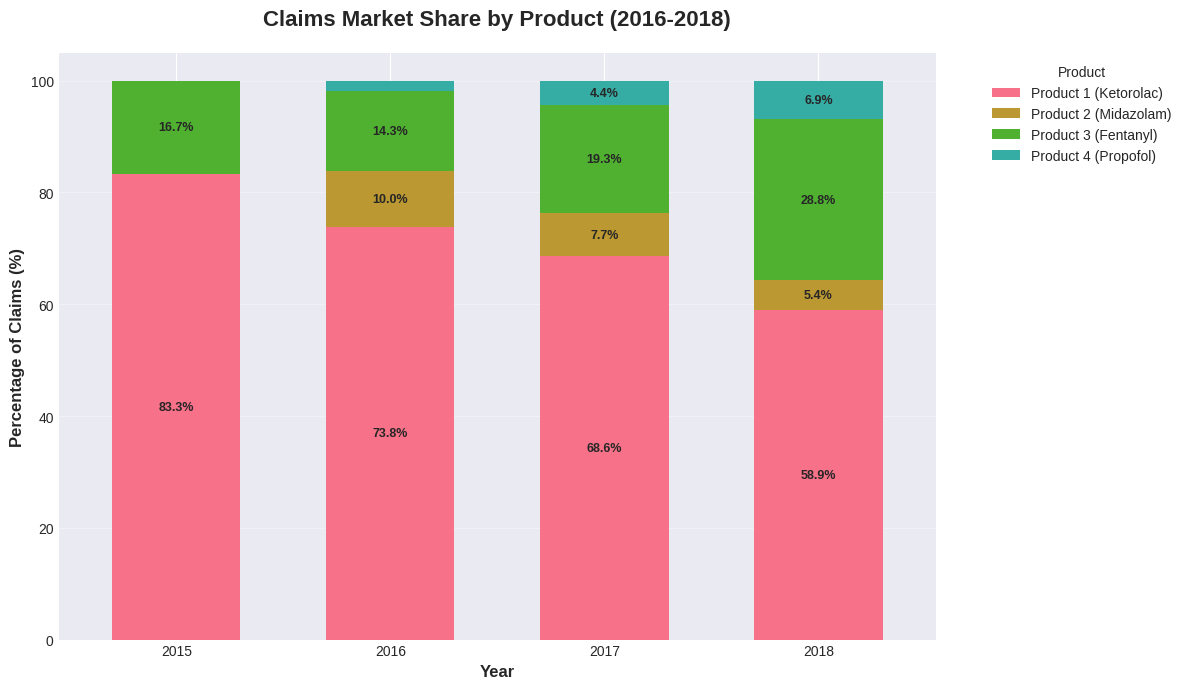

In [59]:
# Prepare data for plotting
claims_plot_data = claims_pct_norm.T

# Create figure
fig, ax = plt.subplots(figsize=(12, 7))

# Create 100% stacked bar chart
claims_plot_data.plot(kind='bar', stacked=True, ax=ax, width=0.6)

# Formatting
ax.set_title('Claims Market Share by Product (2016-2018)', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Year', fontsize=12, fontweight='bold')
ax.set_ylabel('Percentage of Claims (%)', fontsize=12, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title='Product', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
ax.grid(axis='y', alpha=0.3)

# Add percentage labels on bars
for container in ax.containers:
    labels = [f'{v:.1f}%' if v > 3 else '' for v in container.datavalues]
    ax.bar_label(container, labels=labels, label_type='center', fontsize=9, weight='bold')

plt.tight_layout()
plt.savefig('Q1a_Claims_Percentage.png', dpi=300, bbox_inches='tight')
plt.show()

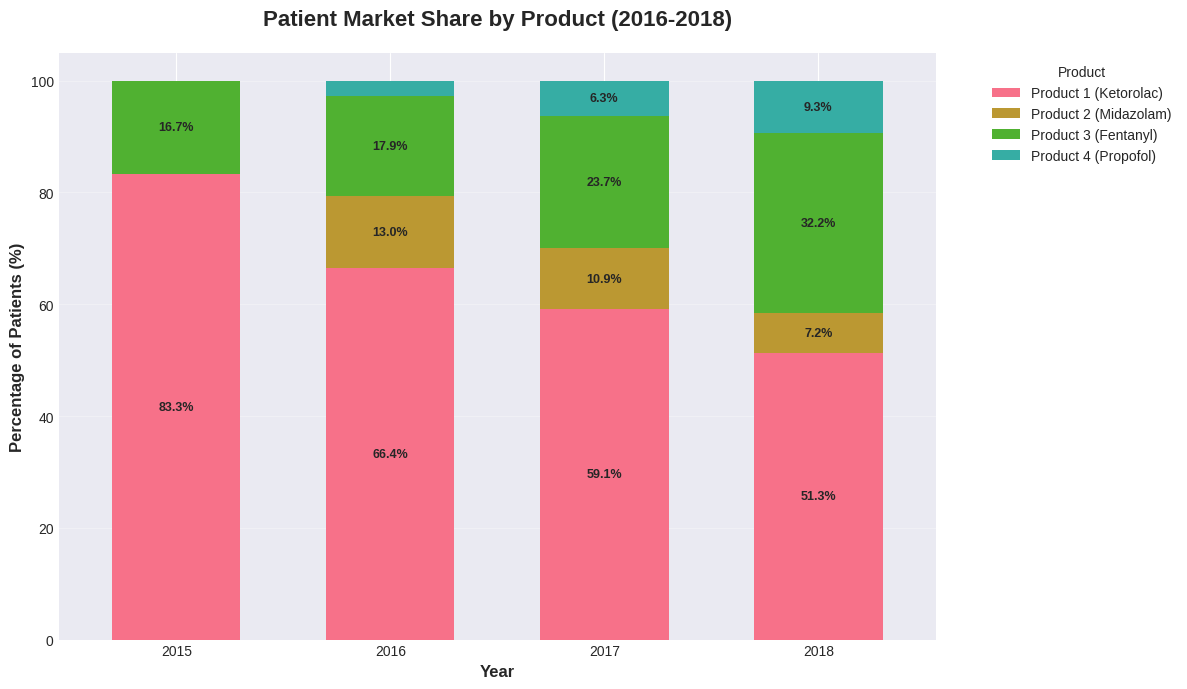

In [60]:
# Prepare data for plotting
patients_plot_data = patients_pct_norm.T

# Create figure
fig, ax = plt.subplots(figsize=(12, 7))

# Create 100% stacked bar chart
patients_plot_data.plot(kind='bar', stacked=True, ax=ax, width=0.6)

# Formatting
ax.set_title('Patient Market Share by Product (2016-2018)', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Year', fontsize=12, fontweight='bold')
ax.set_ylabel('Percentage of Patients (%)', fontsize=12, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title='Product', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
ax.grid(axis='y', alpha=0.3)

# Add percentage labels on bars
for container in ax.containers:
    labels = [f'{v:.1f}%' if v > 3 else '' for v in container.datavalues]
    ax.bar_label(container, labels=labels, label_type='center', fontsize=9, weight='bold')

plt.tight_layout()
plt.savefig('Q1a_Patients_Percentage.png', dpi=300, bbox_inches='tight')
plt.show()

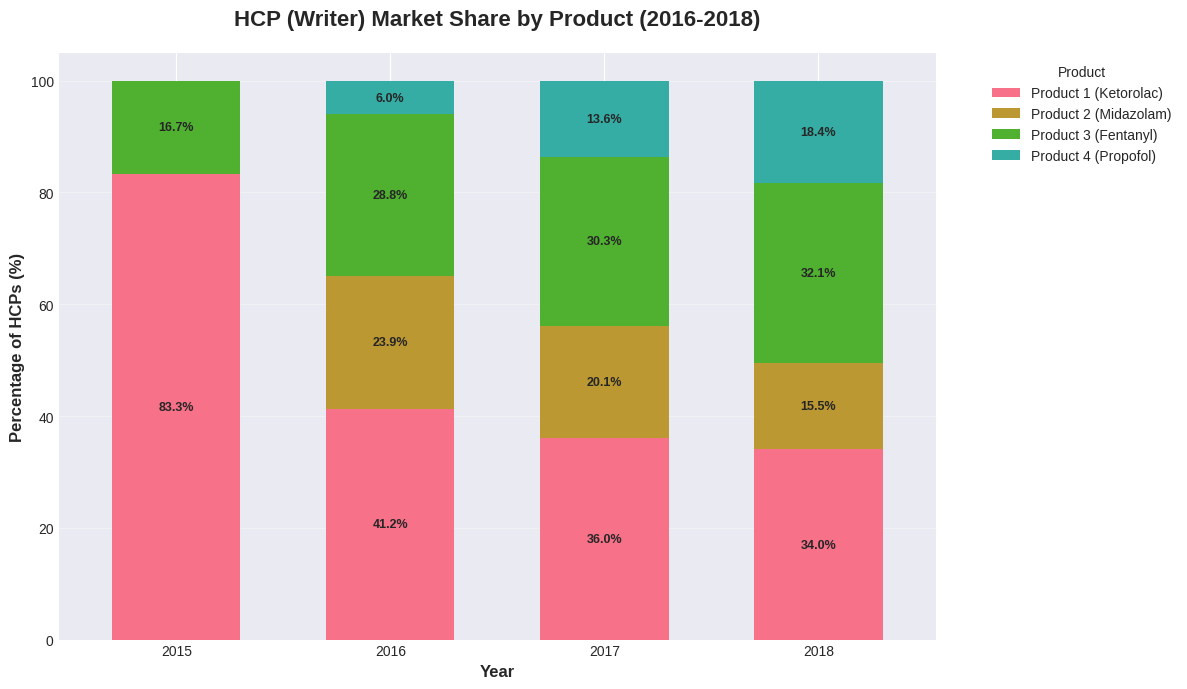

In [61]:
# Prepare data for plotting
hcps_plot_data = hcps_pct_norm.T

# Create figure
fig, ax = plt.subplots(figsize=(12, 7))

# Create 100% stacked bar chart
hcps_plot_data.plot(kind='bar', stacked=True, ax=ax, width=0.6)

# Formatting
ax.set_title('HCP (Writer) Market Share by Product (2016-2018)', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Year', fontsize=12, fontweight='bold')
ax.set_ylabel('Percentage of HCPs (%)', fontsize=12, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title='Product', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
ax.grid(axis='y', alpha=0.3)

# Add percentage labels on bars
for container in ax.containers:
    labels = [f'{v:.1f}%' if v > 3 else '' for v in container.datavalues]
    ax.bar_label(container, labels=labels, label_type='center', fontsize=9, weight='bold')

plt.tight_layout()
plt.savefig('Q1a_HCPs_Percentage.png', dpi=300, bbox_inches='tight')
plt.show()

OBSERVATION:
Product 3 (Fentanyl - Competitor) is rapidly gaining market share across all
metrics (claims, patients, HCPs) from 2016 to 2018, while Product 2 (Midazolam -
Your New Brand) is losing share instead of capturing Product 1's declining market.

RECOMMENDATIONS:
1. Immediately investigate why HCPs are switching to Product 3 instead of Product 2
2. Conduct competitive intelligence on Product 3's value proposition and pricing
3. Enhance sales force messaging to position Product 2 as the natural transition
   from Product 1

Q1b: Writer Productivity Analysis

In [62]:
print("\nQ1b: Writer Productivity Analysis")

# Calculate claims per writer
claims_per_writer = df_market.groupby(['claim_year', 'Product_Name']).agg({
    'cur_clm_uniq_id': 'count',  # Total claims
    'fac_prvdr_npi_num': 'nunique'  # Unique writers
}).reset_index()

claims_per_writer.columns = ['claim_year', 'Product_Name', 'total_claims', 'total_writers']
claims_per_writer['claims_per_writer'] = claims_per_writer['total_claims'] / claims_per_writer['total_writers']

print("\n1. Claims per Writer by Product and Year:")
print(claims_per_writer.pivot(index='Product_Name', columns='claim_year', values='claims_per_writer').round(2))

# Calculate patients per writer
patients_per_writer = df_market.groupby(['claim_year', 'Product_Name']).agg({
    'bene_mbi_id': 'nunique',  # Unique patients
    'fac_prvdr_npi_num': 'nunique'  # Unique writers
}).reset_index()

patients_per_writer.columns = ['claim_year', 'Product_Name', 'total_patients', 'total_writers']
patients_per_writer['patients_per_writer'] = patients_per_writer['total_patients'] / patients_per_writer['total_writers']

print("\n2. Patients per Writer by Product and Year:")
print(patients_per_writer.pivot(index='Product_Name', columns='claim_year', values='patients_per_writer').round(2))


Q1b: Writer Productivity Analysis

1. Claims per Writer by Product and Year:
claim_year             2015  2016  2017  2018
Product_Name                                 
Product 1 (Ketorolac)   1.0  6.41  7.46  6.65
Product 2 (Midazolam)   NaN  1.51  1.51  1.34
Product 3 (Fentanyl)    1.0  1.77  2.50  3.45
Product 4 (Propofol)    NaN  1.12  1.27  1.44

2. Patients per Writer by Product and Year:
claim_year             2015  2016  2017  2018
Product_Name                                 
Product 1 (Ketorolac)   1.0  4.10  4.35  4.07
Product 2 (Midazolam)   NaN  1.39  1.44  1.25
Product 3 (Fentanyl)    1.0  1.58  2.07  2.71
Product 4 (Propofol)    NaN  1.12  1.22  1.37


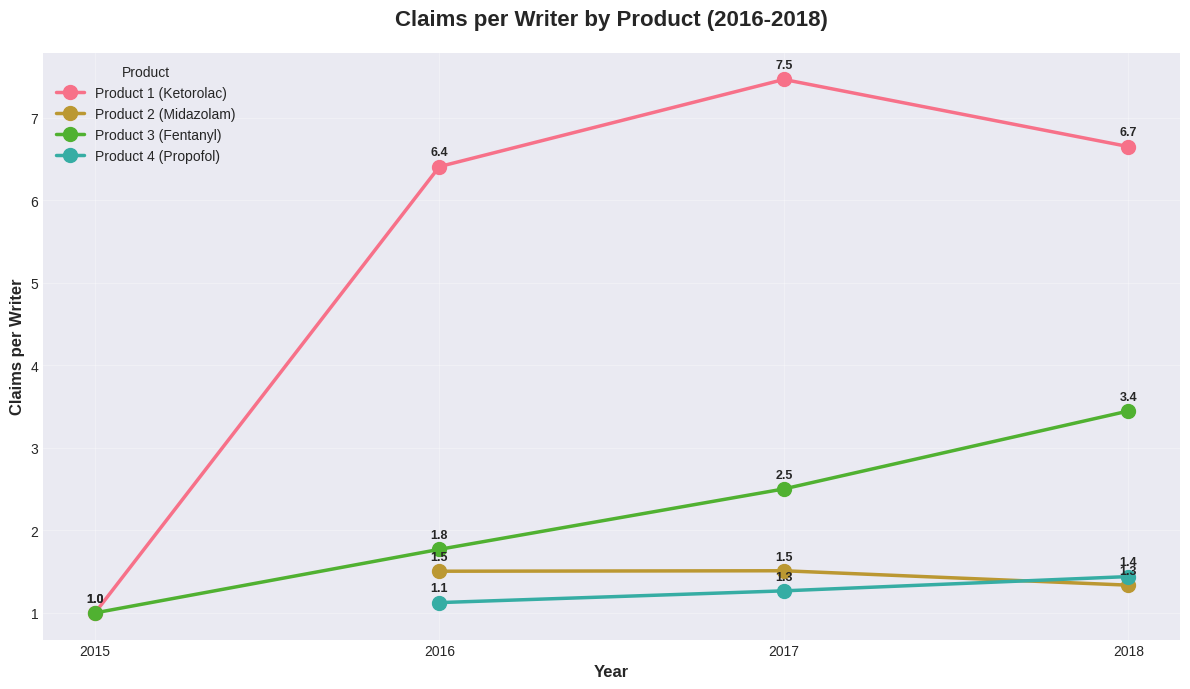

In [63]:
# Prepare data
pivot_claims_per_writer = claims_per_writer.pivot(index='claim_year', columns='Product_Name', values='claims_per_writer')

# Create figure
fig, ax = plt.subplots(figsize=(12, 7))

# Plot lines for each product
for product in pivot_claims_per_writer.columns:
    ax.plot(pivot_claims_per_writer.index, pivot_claims_per_writer[product],
            marker='o', linewidth=2.5, markersize=10, label=product)

# Formatting
ax.set_title('Claims per Writer by Product (2016-2018)', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Year', fontsize=12, fontweight='bold')
ax.set_ylabel('Claims per Writer', fontsize=12, fontweight='bold')
ax.legend(title='Product', fontsize=10, loc='best')
ax.grid(True, alpha=0.3)
ax.set_xticks(pivot_claims_per_writer.index)

# Add value labels on points
for product in pivot_claims_per_writer.columns:
    for year in pivot_claims_per_writer.index:
        value = pivot_claims_per_writer.loc[year, product]
        ax.annotate(f'{value:.1f}', xy=(year, value),
                   textcoords="offset points", xytext=(0,8),
                   ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('Q1b_Claims_per_Writer.png', dpi=300, bbox_inches='tight')
plt.show()

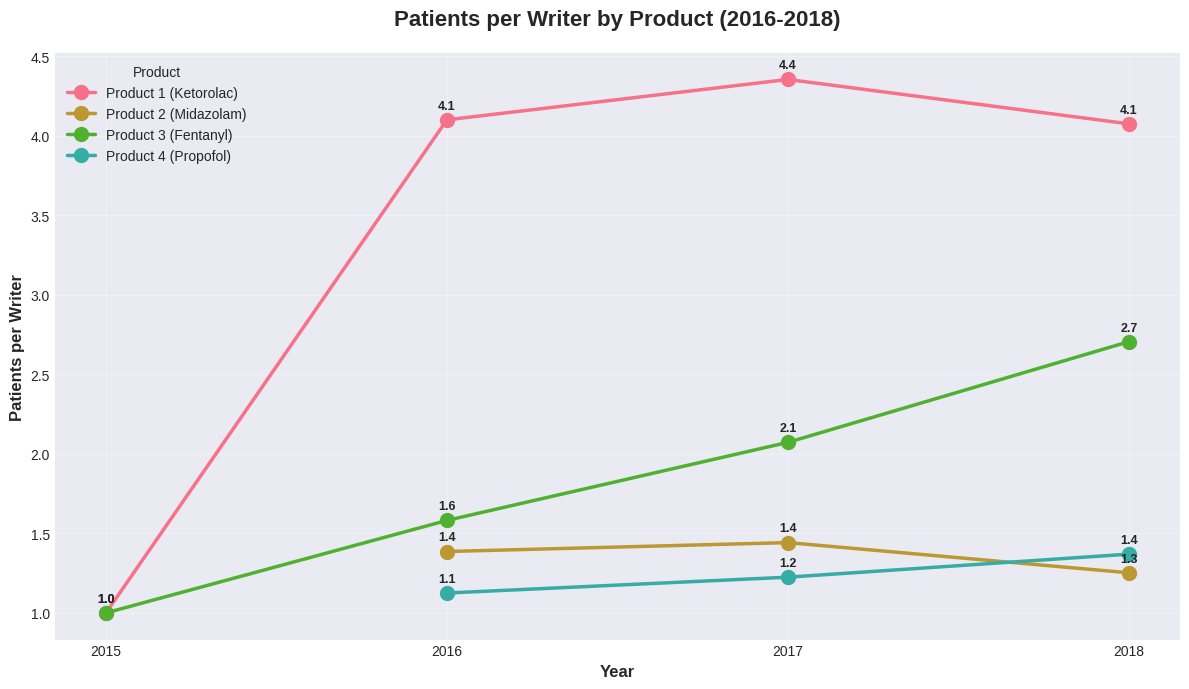

In [64]:
# Prepare data
pivot_patients_per_writer = patients_per_writer.pivot(index='claim_year', columns='Product_Name', values='patients_per_writer')

# Create figure
fig, ax = plt.subplots(figsize=(12, 7))

# Plot lines for each product
for product in pivot_patients_per_writer.columns:
    ax.plot(pivot_patients_per_writer.index, pivot_patients_per_writer[product],
            marker='o', linewidth=2.5, markersize=10, label=product)

# Formatting
ax.set_title('Patients per Writer by Product (2016-2018)', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Year', fontsize=12, fontweight='bold')
ax.set_ylabel('Patients per Writer', fontsize=12, fontweight='bold')
ax.legend(title='Product', fontsize=10, loc='best')
ax.grid(True, alpha=0.3)
ax.set_xticks(pivot_patients_per_writer.index)

# Add value labels on points
for product in pivot_patients_per_writer.columns:
    for year in pivot_patients_per_writer.index:
        value = pivot_patients_per_writer.loc[year, product]
        ax.annotate(f'{value:.1f}', xy=(year, value),
                   textcoords="offset points", xytext=(0,8),
                   ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('Q1b_Patients_per_Writer.png', dpi=300, bbox_inches='tight')
plt.show()

OBSERVATION:
Product 3 (Fentanyl) writers are significantly more productive with higher claims
per writer and patients per writer compared to Product 2 (Midazolam). This suggests
Product 3 is becoming the preferred choice among prescribers.

RECOMMENDATIONS:
1. Train sales force to increase Product 2 prescription frequency among existing writers
2. Provide clinical evidence and educational materials highlighting Product 2's benefits
3. Implement writer engagement programs to build loyalty and increase prescribing habits


In [65]:
print("\nQ1c: Territory Analysis - Product 2 Decline")

# Get territory-level claims by product and year
territory_claims = df_market.groupby(['Territory Name', 'claim_year', 'Product_Name']).size().reset_index(name='claim_count')

# Focus on Product 2 (Midazolam)
product2_territory = territory_claims[territory_claims['Product_Name'] == 'Product 2 (Midazolam)'].copy()

# Pivot to get 2017 and 2018 side by side
product2_pivot = product2_territory.pivot_table(
    index='Territory Name',
    columns='claim_year',
    values='claim_count',
    fill_value=0
)

# Calculate year-over-year change % from 2017 to 2018
if 2017 in product2_pivot.columns and 2018 in product2_pivot.columns:
    product2_pivot['yoy_change_%'] = ((product2_pivot[2018] - product2_pivot[2017]) /
                                       product2_pivot[2017].replace(0, np.nan)) * 100

    # Sort by smallest (most negative) change
    product2_pivot_sorted = product2_pivot.sort_values('yoy_change_%')

    # Get top 5 territories with biggest drop
    top5_declining_territories = product2_pivot_sorted.head(5).index.tolist()

    print("\nTop 5 Territories with Biggest Drop in Product 2 Claims (2017→2018):")
    print(product2_pivot_sorted.head(5)[['yoy_change_%', 2017, 2018]])
else:
    print("\nWarning: 2017 or 2018 data not available")
    top5_declining_territories = []



Q1c: Territory Analysis - Product 2 Decline

Top 5 Territories with Biggest Drop in Product 2 Claims (2017→2018):
claim_year        yoy_change_%  2017  2018
Territory Name                            
St Louis, MO        -72.727273  22.0   6.0
Phoenix, AZ         -70.000000  10.0   3.0
LA-San Diego, CA    -57.894737  38.0  16.0
New York, NY        -57.500000  40.0  17.0
Minneapolis, MN     -53.333333  15.0   7.0


In [66]:
if top5_declining_territories:
    # Filter for top 5 territories and both Product 2 and Product 3
    top5_data = territory_claims[
        (territory_claims['Territory Name'].isin(top5_declining_territories)) &
        (territory_claims['Product_Name'].isin(['Product 2 (Midazolam)', 'Product 3 (Fentanyl)']))
    ].copy()

    print("\nClaims Data for Top 5 Declining Territories")

    # Product 2 claims in top 5 territories
    print("\nProduct 2 (Midazolam) Claims:")
    product2_top5 = top5_data[top5_data['Product_Name'] == 'Product 2 (Midazolam)']
    print(product2_top5.pivot_table(index='Territory Name', columns='claim_year',
                                     values='claim_count', fill_value=0))

    # Product 3 claims in top 5 territories
    print("\nProduct 3 (Fentanyl) Claims:")
    product3_top5 = top5_data[top5_data['Product_Name'] == 'Product 3 (Fentanyl)']
    print(product3_top5.pivot_table(index='Territory Name', columns='claim_year',
                                     values='claim_count', fill_value=0))


Claims Data for Top 5 Declining Territories

Product 2 (Midazolam) Claims:
claim_year        2016  2017  2018
Territory Name                    
LA-San Diego, CA  29.0  38.0  16.0
Minneapolis, MN   15.0  15.0   7.0
New York, NY      24.0  40.0  17.0
Phoenix, AZ       11.0  10.0   3.0
St Louis, MO      19.0  22.0   6.0

Product 3 (Fentanyl) Claims:
claim_year        2015  2016  2017   2018
Territory Name                           
LA-San Diego, CA   0.0  55.0  86.0   99.0
Minneapolis, MN    0.0  14.0  37.0   50.0
New York, NY       1.0  33.0  81.0  153.0
Phoenix, AZ        0.0   7.0  23.0   32.0
St Louis, MO       0.0  23.0  40.0   54.0


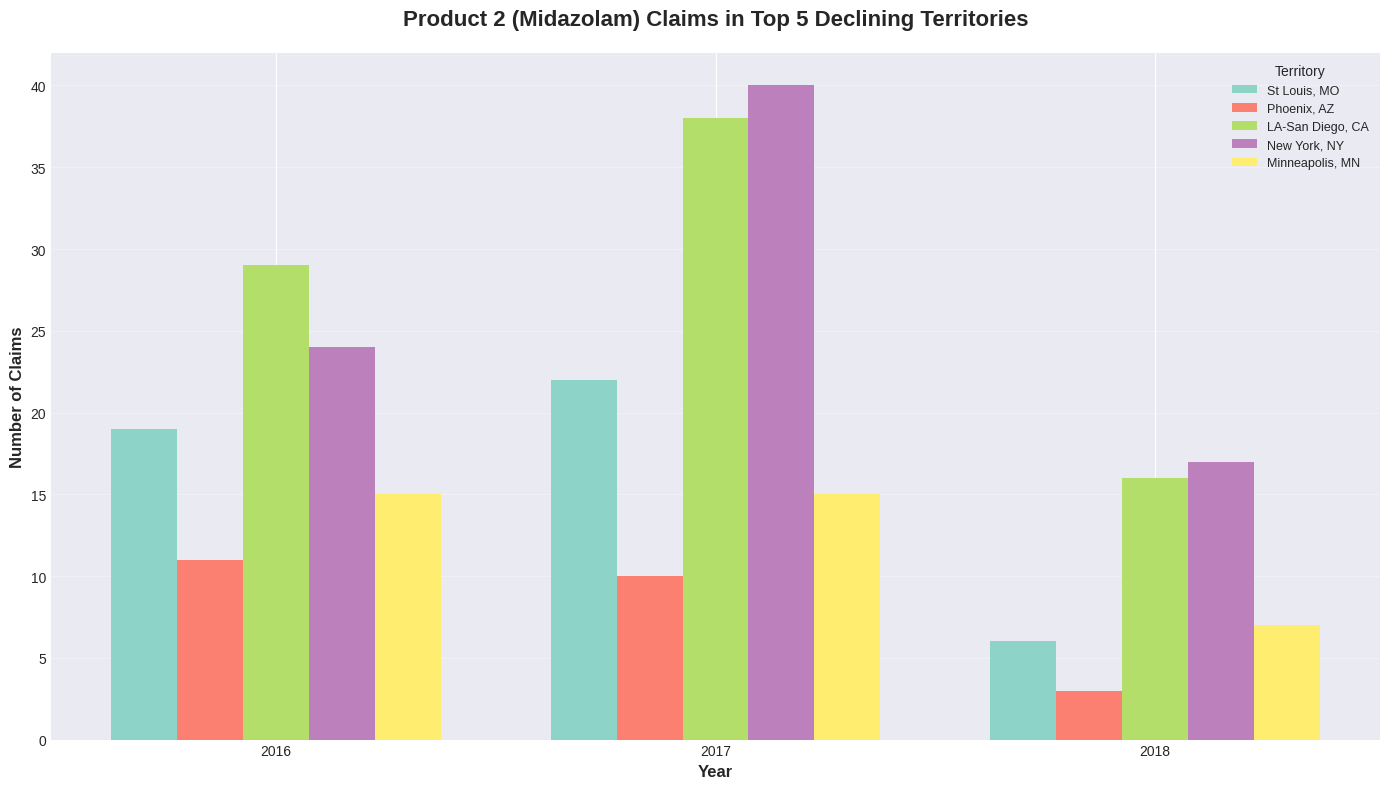

In [67]:
if top5_declining_territories:
    # Prepare data for Product 2
    product2_top5_pivot = product2_top5.pivot_table(
        index='Territory Name',
        columns='claim_year',
        values='claim_count',
        fill_value=0
    )

    # Create figure
    fig, ax = plt.subplots(figsize=(14, 8))

    # Create clustered bar chart
    x = np.arange(len([2016, 2017, 2018]))
    width = 0.15

    colors = plt.cm.Set3(np.linspace(0, 1, len(top5_declining_territories)))

    for i, territory in enumerate(top5_declining_territories):
        if territory in product2_top5_pivot.index:
            values = [product2_top5_pivot.loc[territory, year] if year in product2_top5_pivot.columns
                     else 0 for year in [2016, 2017, 2018]]
            ax.bar(x + i*width, values, width, label=territory, color=colors[i])

    # Formatting
    ax.set_title('Product 2 (Midazolam) Claims in Top 5 Declining Territories',
                 fontsize=16, fontweight='bold', pad=20)
    ax.set_xlabel('Year', fontsize=12, fontweight='bold')
    ax.set_ylabel('Number of Claims', fontsize=12, fontweight='bold')
    ax.set_xticks(x + width * 2)
    ax.set_xticklabels([2016, 2017, 2018])
    ax.legend(title='Territory', fontsize=9, loc='upper right')
    ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.savefig('Q1c_Product2_Top5_Territories.png', dpi=300, bbox_inches='tight')
    plt.show()

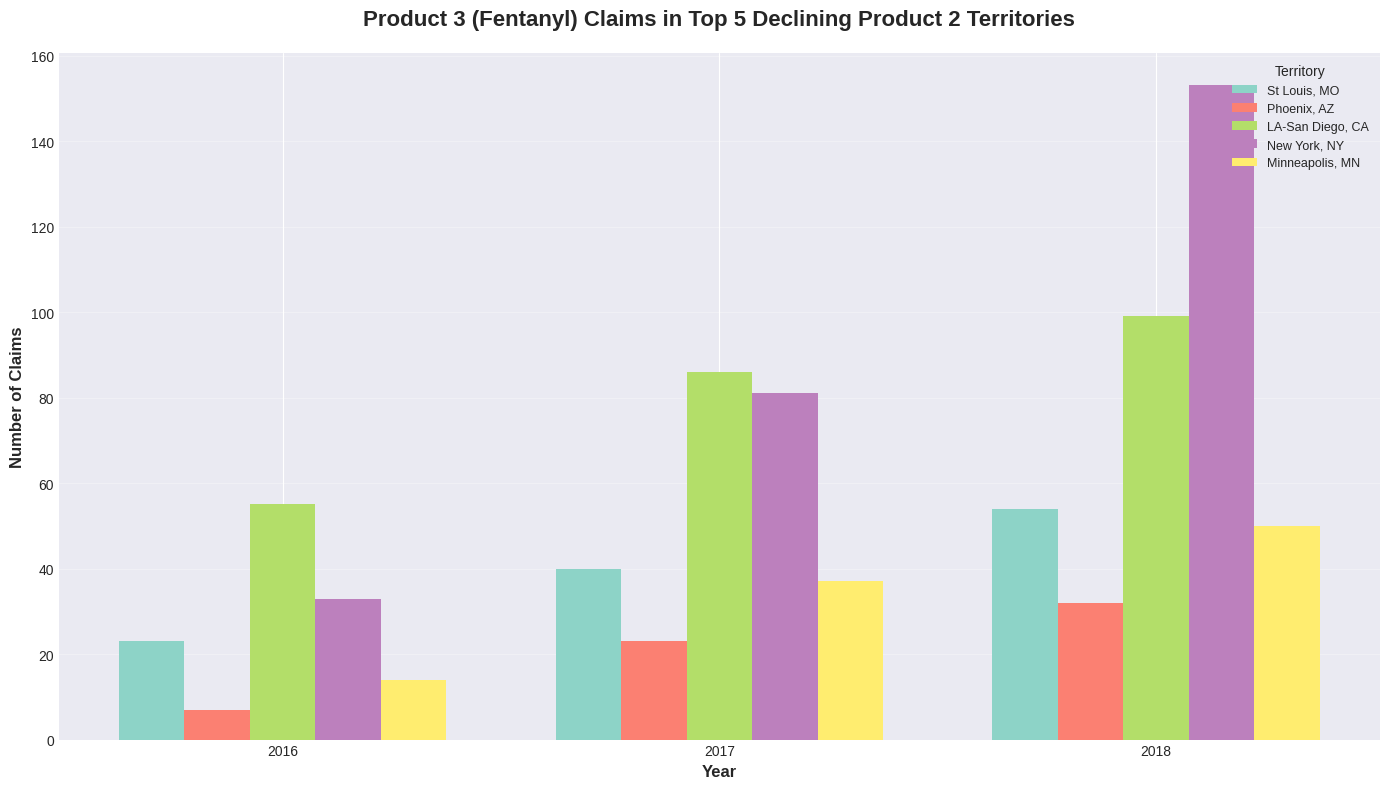

In [68]:
if top5_declining_territories:
    # Prepare data for Product 3
    product3_top5_pivot = product3_top5.pivot_table(
        index='Territory Name',
        columns='claim_year',
        values='claim_count',
        fill_value=0
    )

    # Create figure
    fig, ax = plt.subplots(figsize=(14, 8))

    # Create clustered bar chart
    x = np.arange(len([2016, 2017, 2018]))
    width = 0.15

    colors = plt.cm.Set3(np.linspace(0, 1, len(top5_declining_territories)))

    for i, territory in enumerate(top5_declining_territories):
        if territory in product3_top5_pivot.index:
            values = [product3_top5_pivot.loc[territory, year] if year in product3_top5_pivot.columns
                     else 0 for year in [2016, 2017, 2018]]
            ax.bar(x + i*width, values, width, label=territory, color=colors[i])

    # Formatting
    ax.set_title('Product 3 (Fentanyl) Claims in Top 5 Declining Product 2 Territories',
                 fontsize=16, fontweight='bold', pad=20)
    ax.set_xlabel('Year', fontsize=12, fontweight='bold')
    ax.set_ylabel('Number of Claims', fontsize=12, fontweight='bold')
    ax.set_xticks(x + width * 2)
    ax.set_xticklabels([2016, 2017, 2018])
    ax.legend(title='Territory', fontsize=9, loc='upper right')
    ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.savefig('Q1c_Product3_Top5_Territories.png', dpi=300, bbox_inches='tight')
    plt.show()

OBSERVATION:
In territories where Product 2 is declining most sharply, Product 3 is showing
corresponding growth, confirming direct market share capture by the competitor.

RECOMMENDATIONS:
1. Deploy additional sales resources to these high-priority declining territories
2. Conduct Win-Loss analysis to understand why HCPs are switching to Product 3
3. Implement territory-specific promotional campaigns and HCP engagement initiatives


QUESTION 2: KEY MARKET DRIVERS

In [69]:
print("\nQ2a: Specialty Distribution Analysis")

# 1. DIAGNOSIS SPECIALTY ANALYSIS (Top 5)
diagnosis_specialty_dist = df_market['Diagnosis_Specialty'].value_counts()

print("\n1. Diagnosis Specialty Distribution (All):")
print(diagnosis_specialty_dist)

# Get top 5 diagnosis specialties
top5_diagnosis = diagnosis_specialty_dist.head(5)
print("\n   Top 5 Diagnosis Specialties:")
print(top5_diagnosis)
print(f"\n   Top 5 represent {top5_diagnosis.sum() / diagnosis_specialty_dist.sum() * 100:.1f}% of all claims")

# 2. HCP SPECIALTY ANALYSIS
hcp_specialty_dist = df_market.groupby('HCP_Specialty')['fac_prvdr_npi_num'].nunique().sort_values(ascending=False)

print("\n2. HCP Specialty Distribution (Number of Writers):")
print(hcp_specialty_dist)


Q2a: Specialty Distribution Analysis

1. Diagnosis Specialty Distribution (All):
Diagnosis_Specialty
Circulatory System                                                      7332
Factors Influencing Health Status and Contact with Health Services      1821
Symptoms, Signs and Abnormal Clinical and Lab Findings                  1287
Musculoskeletal and Connective Tissue                                   1195
Endocrine, Nutritional, Metabolic                                        762
Digestive System                                                         582
Genitourinary System                                                     475
Respiratory System                                                       393
Mental and Behavioral Disorders                                          292
Eye and Adnexa, Ear and Mastoid Process                                  249
Neoplasms, Blood, Blood-forming Organs                                   228
Nervous System                                     

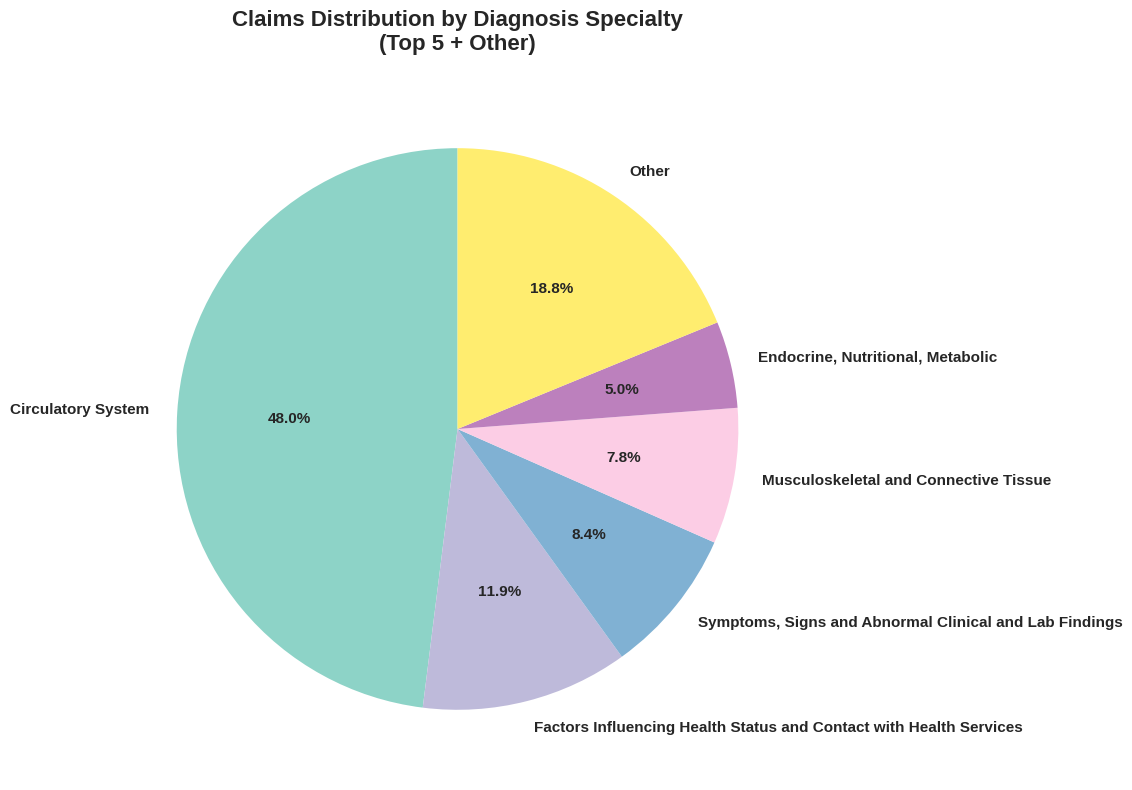

In [70]:
# Calculate percentages for top 5
top5_pct = (top5_diagnosis / diagnosis_specialty_dist.sum() * 100)
other_pct = 100 - top5_pct.sum()

# Prepare data for pie chart (including "Other")
pie_data = top5_pct.to_dict()
pie_data['Other'] = other_pct

# Create figure
fig, ax = plt.subplots(figsize=(12, 8))

# Create pie chart
colors = plt.cm.Set3(np.linspace(0, 1, len(pie_data)))
wedges, texts, autotexts = ax.pie(pie_data.values(), labels=pie_data.keys(),
                                    autopct='%1.1f%%', startangle=90,
                                    colors=colors, textprops={'fontsize': 11, 'weight': 'bold'})

# Formatting
ax.set_title('Claims Distribution by Diagnosis Specialty\n(Top 5 + Other)',
             fontsize=16, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('Q2a_Diagnosis_Specialty_Pie.png', dpi=300, bbox_inches='tight')
plt.show()

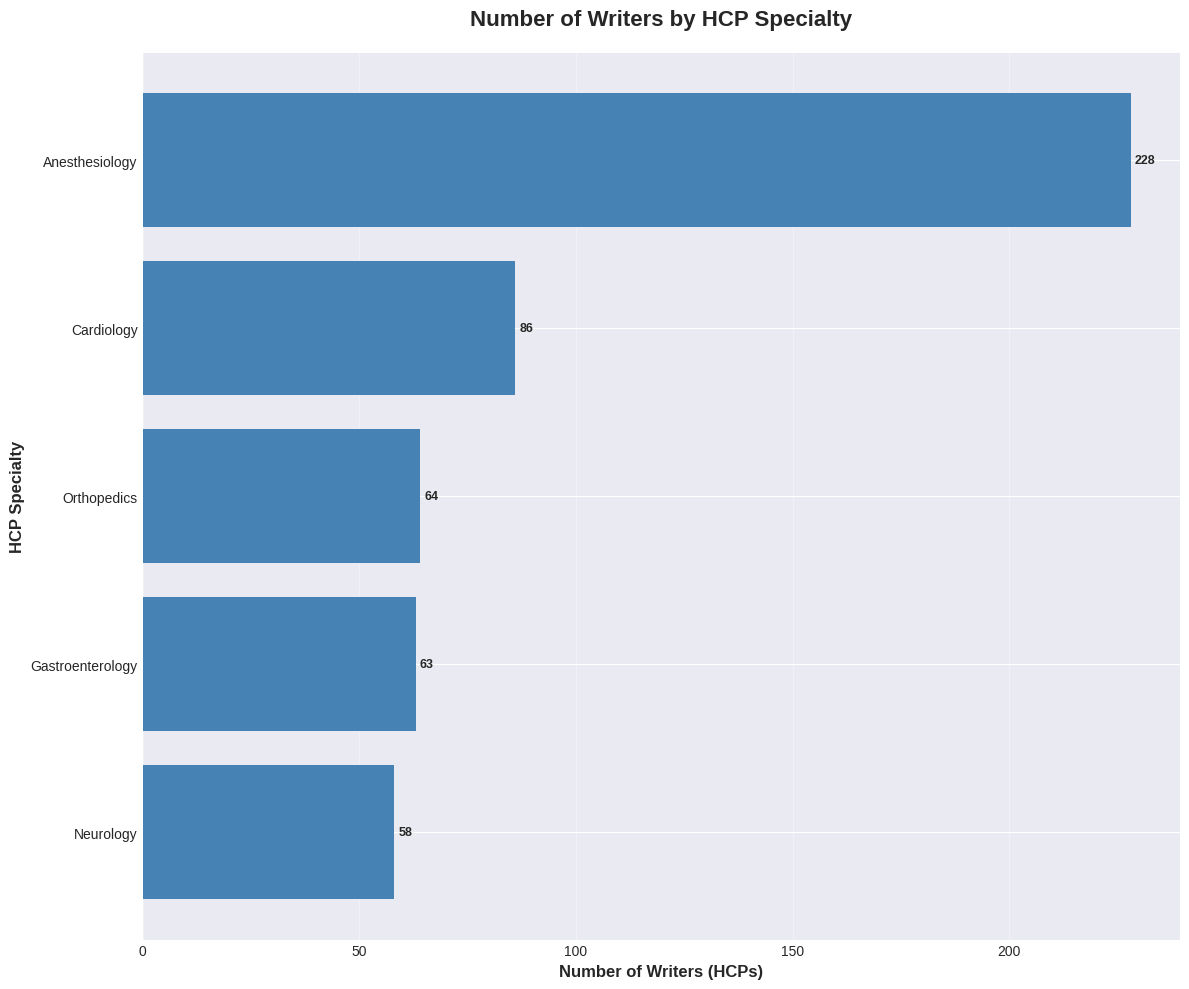

In [71]:
# Prepare data
hcp_specialty_plot = hcp_specialty_dist.sort_values(ascending=True)

# Create figure
fig, ax = plt.subplots(figsize=(12, 10))

# Create horizontal bar chart
bars = ax.barh(range(len(hcp_specialty_plot)), hcp_specialty_plot.values, color='steelblue')

# Formatting
ax.set_yticks(range(len(hcp_specialty_plot)))
ax.set_yticklabels(hcp_specialty_plot.index, fontsize=10)
ax.set_xlabel('Number of Writers (HCPs)', fontsize=12, fontweight='bold')
ax.set_ylabel('HCP Specialty', fontsize=12, fontweight='bold')
ax.set_title('Number of Writers by HCP Specialty', fontsize=16, fontweight='bold', pad=20)
ax.grid(axis='x', alpha=0.3)

# Add value labels
for i, bar in enumerate(bars):
    width = bar.get_width()
    ax.text(width + 1, bar.get_y() + bar.get_height()/2,
            f'{int(width)}', ha='left', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('Q2a_HCP_Specialty_Writers.png', dpi=300, bbox_inches='tight')
plt.show()

OBSERVATION:
Certain diagnosis and HCP specialties dominate the injectable anesthesia market,
indicating concentrated prescribing patterns that should be targeted strategically.

RECOMMENDATIONS:
1. Prioritize sales and marketing efforts toward top diagnosis specialties
2. Develop specialty-specific messaging and clinical materials for high-volume HCP specialties
3. Build Key Opinion Leader (KOL) relationships within dominant specialty groups
""")

In [72]:
print("\nQ2b: Patient Age Distribution Analysis")

# Define age buckets
def categorize_age(age):
    """Categorize age into buckets"""
    if pd.isna(age):
        return 'Unknown'
    elif age < 18:
        return 'Under 18'
    elif 18 <= age <= 30:
        return '18-30'
    elif 31 <= age <= 40:
        return '31-40'
    elif 41 <= age <= 50:
        return '41-50'
    elif 51 <= age <= 60:
        return '51-60'
    elif 61 <= age <= 70:
        return '61-70'
    elif 71 <= age <= 80:
        return '71-80'
    else:
        return '81+'

# Apply age categorization
df_market['age_bucket'] = df_market['Age'].apply(categorize_age)

# 1. PATIENT COUNT BY AGE BUCKET
patients_by_age = df_market.groupby('age_bucket')['bene_mbi_id'].nunique().sort_index()

# Order age buckets properly
age_order = ['18-30', '31-40', '41-50', '51-60', '61-70', '71-80', '81+']
patients_by_age = patients_by_age.reindex([a for a in age_order if a in patients_by_age.index])

print("\n1. Number of Patients by Age Bucket:")
print(patients_by_age)

# 2. CLAIMS PERCENTAGE BY AGE BUCKET
claims_by_age = df_market.groupby('age_bucket').size()
claims_by_age_pct = (claims_by_age / claims_by_age.sum() * 100)
claims_by_age_pct = claims_by_age_pct.reindex([a for a in age_order if a in claims_by_age_pct.index])

print("\n2. Percentage of Claims by Age Bucket:")
print(claims_by_age_pct.round(2))



Q2b: Patient Age Distribution Analysis

1. Number of Patients by Age Bucket:
age_bucket
18-30    499
31-40    412
41-50    388
51-60    474
61-70    779
71-80    643
81+      553
Name: bene_mbi_id, dtype: int64

2. Percentage of Claims by Age Bucket:
age_bucket
18-30    13.01
31-40    10.53
41-50     9.61
51-60    12.48
61-70    21.18
71-80    17.72
81+      15.48
dtype: float64


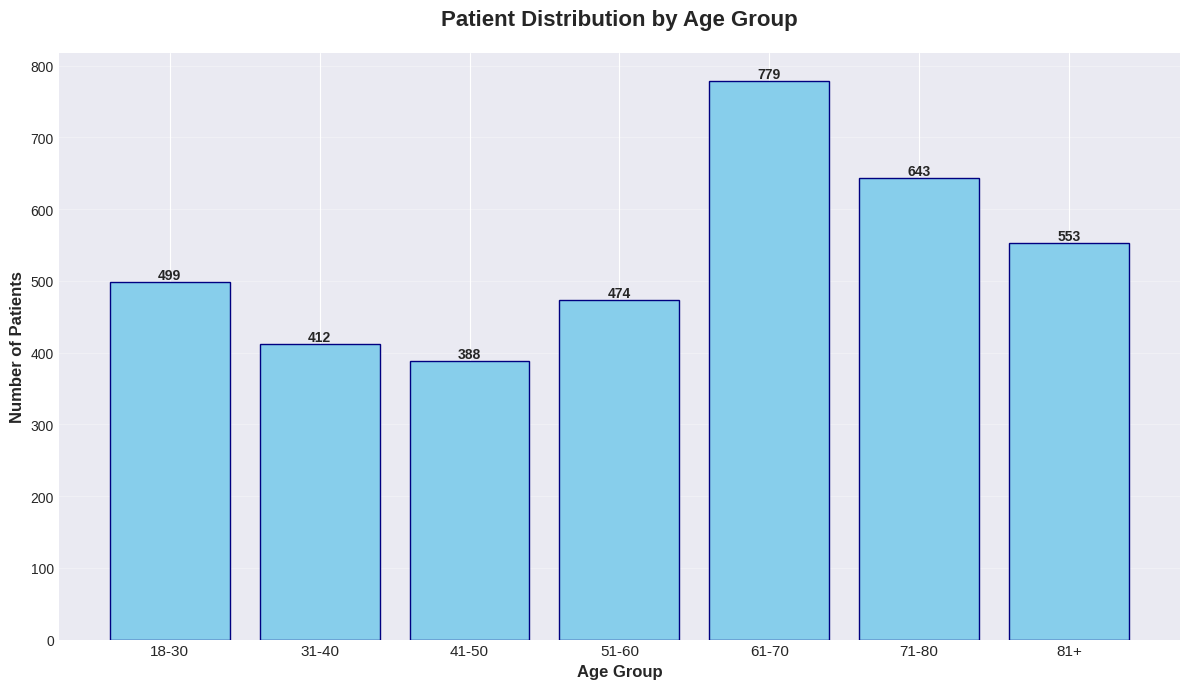

In [73]:
# Create figure
fig, ax = plt.subplots(figsize=(12, 7))

# Create bar chart
bars = ax.bar(range(len(patients_by_age)), patients_by_age.values, color='skyblue', edgecolor='navy')

# Formatting
ax.set_xticks(range(len(patients_by_age)))
ax.set_xticklabels(patients_by_age.index, fontsize=11)
ax.set_xlabel('Age Group', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Patients', fontsize=12, fontweight='bold')
ax.set_title('Patient Distribution by Age Group', fontsize=16, fontweight='bold', pad=20)
ax.grid(axis='y', alpha=0.3)

# Add value labels
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('Q2b_Patients_by_Age.png', dpi=300, bbox_inches='tight')
plt.show()

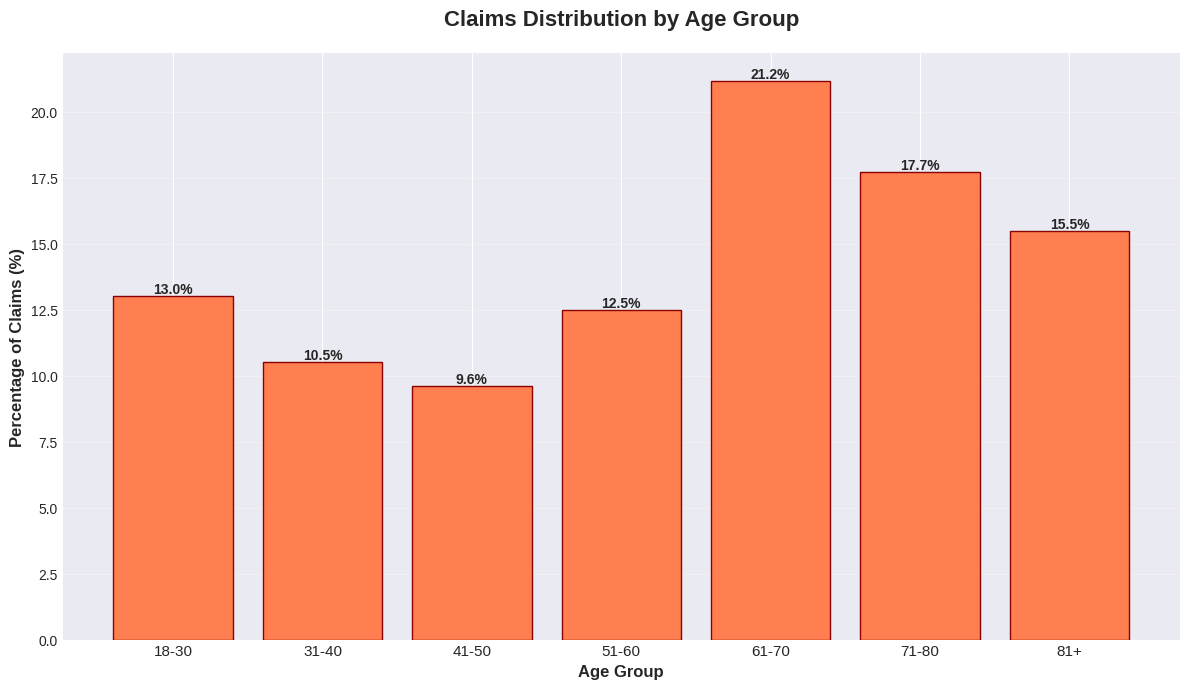

In [74]:
# Create figure
fig, ax = plt.subplots(figsize=(12, 7))

# Create bar chart
bars = ax.bar(range(len(claims_by_age_pct)), claims_by_age_pct.values,
              color='coral', edgecolor='darkred')

# Formatting
ax.set_xticks(range(len(claims_by_age_pct)))
ax.set_xticklabels(claims_by_age_pct.index, fontsize=11)
ax.set_xlabel('Age Group', fontsize=12, fontweight='bold')
ax.set_ylabel('Percentage of Claims (%)', fontsize=12, fontweight='bold')
ax.set_title('Claims Distribution by Age Group', fontsize=16, fontweight='bold', pad=20)
ax.grid(axis='y', alpha=0.3)

# Add value labels
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('Q2b_Claims_by_Age_Percent.png', dpi=300, bbox_inches='tight')
plt.show()

OBSERVATION:
Older age groups (61+) represent the majority of injectable anesthesia patients and
claims, reflecting the aging population's higher surgical procedure rates.

RECOMMENDATIONS:
1. Tailor Product 2 messaging to address safety and efficacy in elderly populations
2. Target HCPs who treat predominantly senior patients (geriatricians, orthopedic surgeons)
3. Develop patient assistance programs for Medicare-eligible populations

In [75]:
print("\nQ2c: New and Continuing Writer Trends")

# For each product, identify the first year each HCP wrote a prescription
first_prescription_year = df_market.groupby(['Product_Name', 'fac_prvdr_npi_num'])['claim_year'].min().reset_index()
first_prescription_year.columns = ['Product_Name', 'HCP_ID', 'first_prescription_year']

# Merge back to get first prescription year for each claim
df_market_with_first = df_market.merge(first_prescription_year,
                                        left_on=['Product_Name', 'fac_prvdr_npi_num'],
                                        right_on=['Product_Name', 'HCP_ID'],
                                        how='left')

# Identify new writers: HCPs whose first prescription year = current claim year
df_market_with_first['is_new_writer'] = (df_market_with_first['claim_year'] ==
                                          df_market_with_first['first_prescription_year'])

# Count new writers by product and year
new_writers = df_market_with_first[df_market_with_first['is_new_writer']].groupby(
    ['claim_year', 'Product_Name'])['fac_prvdr_npi_num'].nunique().reset_index()
new_writers.columns = ['claim_year', 'Product_Name', 'new_writers']

print("\n1. New Writers by Product and Year:")
print(new_writers.pivot(index='Product_Name', columns='claim_year', values='new_writers'))

# Calculate total writers by product and year
total_writers = df_market.groupby(['claim_year', 'Product_Name'])['fac_prvdr_npi_num'].nunique().reset_index()
total_writers.columns = ['claim_year', 'Product_Name', 'total_writers']

# Merge and calculate continuing writers
writer_analysis = total_writers.merge(new_writers, on=['claim_year', 'Product_Name'], how='left')
writer_analysis['new_writers'] = writer_analysis['new_writers'].fillna(0)
writer_analysis['continuing_writers'] = writer_analysis['total_writers'] - writer_analysis['new_writers']

print("\n2. Continuing Writers by Product and Year:")
continuing_pivot = writer_analysis.pivot(index='Product_Name', columns='claim_year', values='continuing_writers')
print(continuing_pivot)

# Focus on 2017-2018 for continuing writers as per instructions
continuing_2017_2018 = writer_analysis[writer_analysis['claim_year'].isin([2017, 2018])].copy()



Q2c: New and Continuing Writer Trends

1. New Writers by Product and Year:
claim_year             2015   2016   2017   2018
Product_Name                                    
Product 1 (Ketorolac)   5.0  487.0    7.0    NaN
Product 2 (Midazolam)   NaN  285.0  111.0   34.0
Product 3 (Fentanyl)    1.0  343.0  119.0   32.0
Product 4 (Propofol)    NaN   72.0  152.0  140.0

2. Continuing Writers by Product and Year:
claim_year             2015  2016   2017   2018
Product_Name                                   
Product 1 (Ketorolac)   0.0   5.0  488.0  496.0
Product 2 (Midazolam)   NaN   0.0  165.0  192.0
Product 3 (Fentanyl)    0.0   1.0  297.0  436.0
Product 4 (Propofol)    NaN   0.0   35.0  128.0


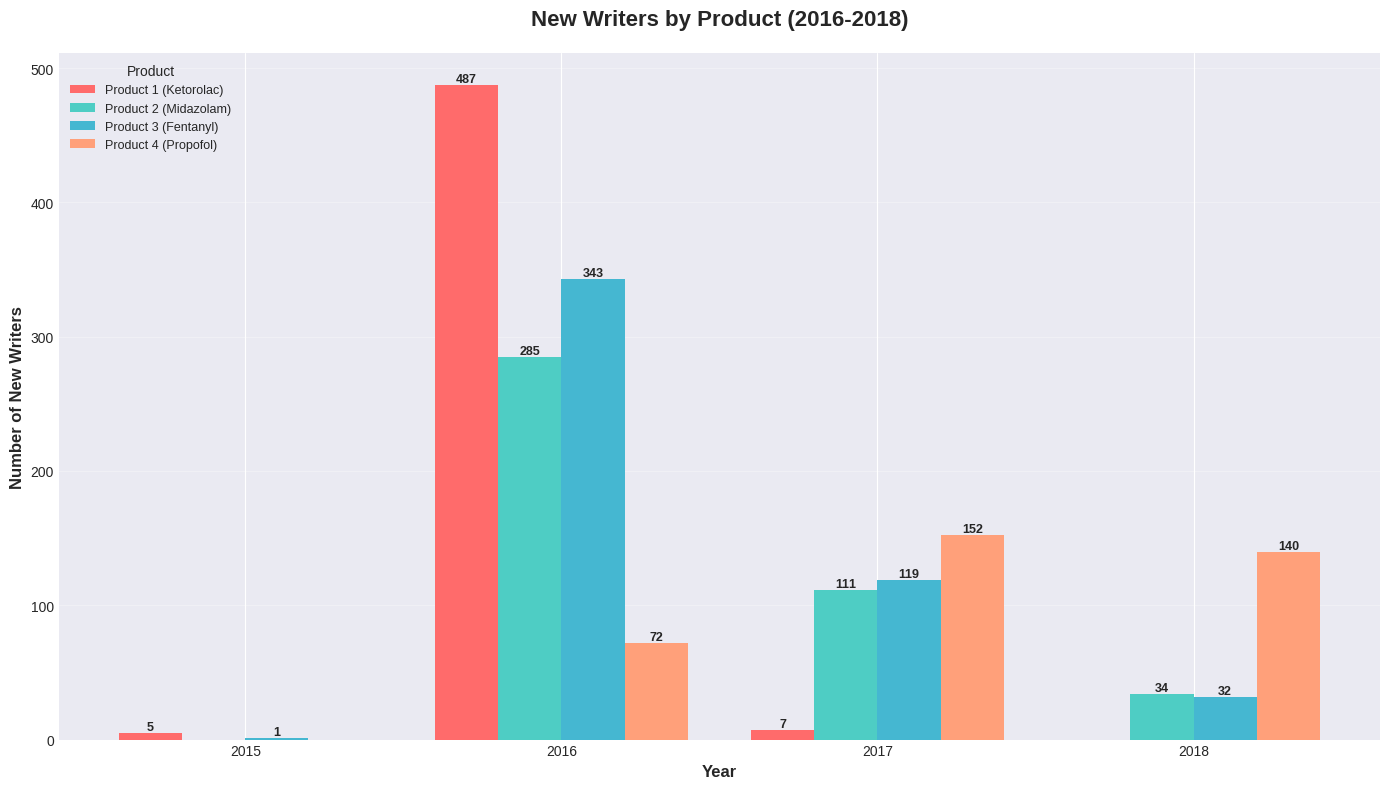

In [76]:
# Pivot data for plotting
new_writers_pivot = new_writers.pivot(index='claim_year', columns='Product_Name', values='new_writers').fillna(0)

# Create figure
fig, ax = plt.subplots(figsize=(14, 8))

# Create clustered bar chart
x = np.arange(len(new_writers_pivot.index))
width = 0.2
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']

for i, product in enumerate(new_writers_pivot.columns):
    ax.bar(x + i*width, new_writers_pivot[product], width, label=product, color=colors[i])

# Formatting
ax.set_title('New Writers by Product (2016-2018)', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Year', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of New Writers', fontsize=12, fontweight='bold')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(new_writers_pivot.index)
ax.legend(title='Product', fontsize=9, loc='upper left')
ax.grid(axis='y', alpha=0.3)

# Add value labels
for i, product in enumerate(new_writers_pivot.columns):
    for j, year in enumerate(new_writers_pivot.index):
        value = new_writers_pivot.loc[year, product]
        if value > 0:
            ax.text(j + i*width, value, f'{int(value)}',
                   ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('Q2c_New_Writers.png', dpi=300, bbox_inches='tight')
plt.show()

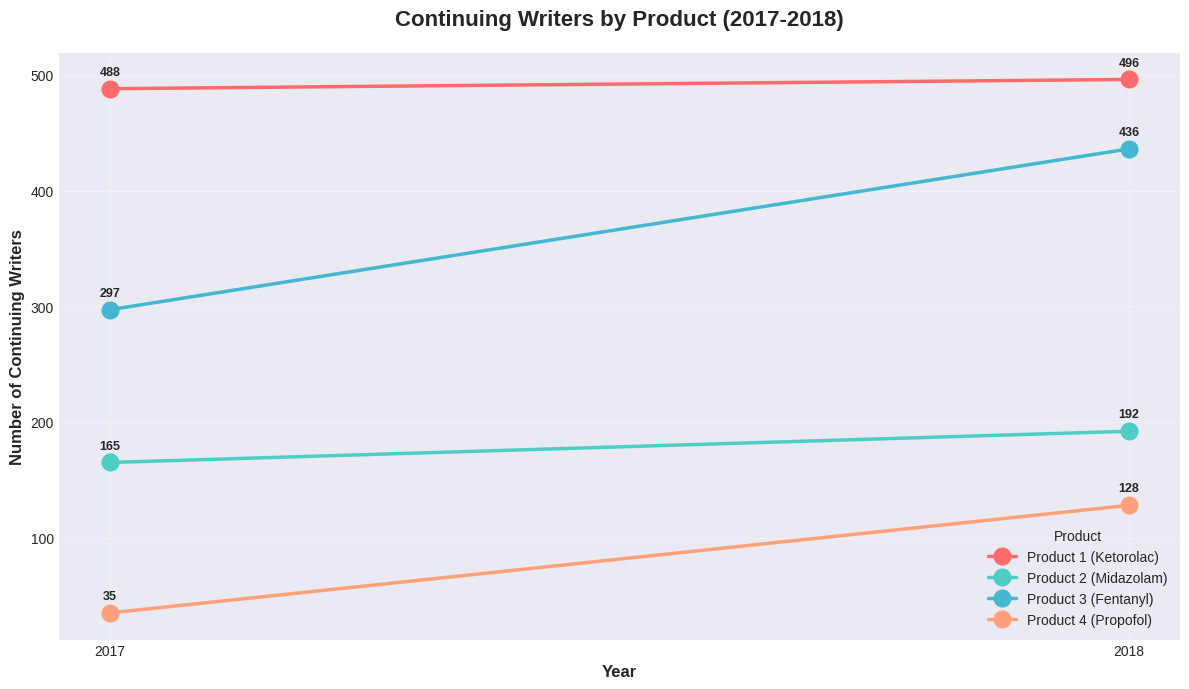

In [77]:
# Prepare data
continuing_plot = continuing_2017_2018.pivot(index='claim_year', columns='Product_Name', values='continuing_writers').fillna(0)

# Create figure
fig, ax = plt.subplots(figsize=(12, 7))

# Plot lines for each product
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']
for i, product in enumerate(continuing_plot.columns):
    ax.plot(continuing_plot.index, continuing_plot[product],
            marker='o', linewidth=2.5, markersize=12, label=product, color=colors[i])

# Formatting
ax.set_title('Continuing Writers by Product (2017-2018)', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Year', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Continuing Writers', fontsize=12, fontweight='bold')
ax.legend(title='Product', fontsize=10, loc='best')
ax.grid(True, alpha=0.3)
ax.set_xticks(continuing_plot.index)

# Add value labels on points
for i, product in enumerate(continuing_plot.columns):
    for year in continuing_plot.index:
        value = continuing_plot.loc[year, product]
        ax.annotate(f'{int(value)}', xy=(year, value),
                   textcoords="offset points", xytext=(0,10),
                   ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('Q2c_Continuing_Writers.png', dpi=300, bbox_inches='tight')
plt.show()

OBSERVATION:
Product 3 (Fentanyl) is attracting more new writers and retaining continuing writers
better than Product 2 (Midazolam), indicating stronger HCP preference and loyalty.

RECOMMENDATIONS:
1. Launch aggressive new writer acquisition campaigns for Product 2 with starter samples
2. Implement retention programs for existing Product 2 writers to prevent switching
3. Conduct peer-to-peer education programs where loyal Product 2 writers share experiences

QUESTION 3: STRATEGIES TO STOP MARKET SHARE EROSION

Key Findings Recap:
1. MARKET SHARE CRISIS:
   - Product 2 is losing share across claims, patients, and HCPs
   - Product 3 (Competitor) is capturing this market share aggressively
   - The intended cannibalization of Product 1 by Product 2 is NOT happening

2. WRITER PRODUCTIVITY GAP:
   - Product 3 writers are more productive (higher claims/writer, patients/writer)
   - Product 2 is failing to build prescription frequency among existing writers

3. GEOGRAPHIC CONCENTRATION:
   - Top 5 declining territories show Product 3 directly replacing Product 2
   - These territories require immediate intervention

4. MARKET DRIVERS:
   - Certain diagnosis specialties and HCP specialties dominate the market
   - Elderly populations (61+) are the primary patient demographic
   - Product 3 is winning both new writers and retaining continuing writers

   Immediate Action Plan:
   PRIORITY 1: TERRITORY-FOCUSED INTERVENTION (Weeks 1-4)

ACTION ITEMS:
• Deploy additional sales force resources to top 5 declining territories
• Conduct intensive HCP engagement in these high-priority areas
• Implement territory-specific promotional campaigns
• Hold local KOL speaker events highlighting Product 2 benefits

EXPECTED OUTCOME:
• Stabilize market share decline in these territories within 60 days
• Increase Product 2 prescriptions by 15% in top 5 territories

BUDGET REQUIRED:
• Additional sales rep allocation: $200K
• Territory-specific promotions: $150K
• Speaker programs: $100K


PRIORITY 2: HCP TARGETING & SEGMENTATION (Weeks 1-8)
ACTION ITEMS:
• Focus on high-volume HCP specialties identified in analysis
• Target HCPs treating diagnosis specialties where Product 2 has advantage
• Develop specialty-specific clinical messaging and materials
• Prioritize elderly patient populations (61+) in messaging

EXPECTED OUTCOME:
• Increase Product 2 adoption in top 3 HCP specialties
• Improve claims per writer metric by 10%

BUDGET REQUIRED:
• Specialty marketing materials: $75K
• Targeted HCP outreach programs: $125K


PRIORITY 3: WRITER ACQUISITION & RETENTION (Weeks 1-12)
ACTION ITEMS:
• Launch new writer acquisition program with starter samples
• Implement retention programs for existing Product 2 writers
• Create switching cost barriers through education and support programs
• Develop peer-to-peer programs with loyal Product 2 prescribers

EXPECTED OUTCOME:
• Acquire 50+ new Product 2 writers per quarter
• Achieve 85% continuing writer retention rate

BUDGET REQUIRED:
• Sample program: $300K
• Writer retention initiatives: $150K
• Peer-to-peer programs: $100K


PRIORITY 4: COMPETITIVE POSITIONING (Ongoing)
ACTION ITEMS:
• Conduct detailed Win-Loss analysis against Product 3
• Understand Product 3's value proposition and counter it
• Strengthen Product 2's clinical differentiation messaging
• Adjust pricing/contracting strategy if needed

EXPECTED OUTCOME:
• Develop competitive counter-positioning strategy
• Win 30% of head-to-head competitions vs Product 3

BUDGET REQUIRED:
• Market research & Win-Loss interviews: $100K
• Competitive intelligence: $50K

Budget and Resource Requirement:
SALES FORCE:
• Increase sales rep allocation to top 5 declining territories by 30%
• Provide intensive training on competitive positioning vs Product 3
• Implement performance incentives tied to Product 2 new writer acquisition
• Weekly coaching sessions focused on Product 2 selling skills

ESTIMATED COST: $500K over 6 months


MARKETING & PROMOTION:
• Increase promotional spend in declining territories by 25%
• Launch targeted direct mail and digital campaigns to HCPs
• Increase speaker program frequency in high-priority specialties
• Develop patient education materials for elderly populations
• Create case studies showcasing Product 2 success stories

ESTIMATED COST: $650K over 6 months


MARKET ACCESS:
• Negotiate favorable formulary positioning
• Implement copay assistance programs
• Ensure Product 2 is preferred over Product 3 in key accounts
• Remove prior authorization barriers where possible

ESTIMATED COST: $200K for programs, potential revenue impact analysis needed


TOTAL BUDGET REQUEST: $1.35M over 6 months
Expected ROI: 3:1 (based on market share stabilization and growth)

Success Metrics:
PRIMARY METRICS:
1. Market Share: Stabilize Product 2 share, then grow by 2% per quarter
   - Target: 25% market share by Q4 2019
   
2. New Writers: Increase new Product 2 writers by 20% quarter-over-quarter
   - Target: 50+ new writers per quarter
   
3. Writer Productivity: Increase claims per writer to match Product 3 levels
   - Target: Close 30% gap within 6 months
   
4. Territory Performance: Reverse decline in top 5 territories within 6 months
   - Target: Positive YoY growth in at least 3 of 5 territories

5. HCP Retention: Achieve 85% continuing writer retention rate
   - Target: <15% writer churn annually

SECONDARY METRICS:
6. Total Prescriptions (TRx): Increase by 10% quarter-over-quarter
7. New Prescriptions (NRx): Increase by 15% quarter-over-quarter
8. Market Share in Target Specialties: Gain 5 points in top 3 specialties
9. Territory Coverage: 90% of high-potential HCPs called on monthly
10. Promotional Response Rate: 25% increase in HCP engagement

LEADING INDICATORS:
• Sales call frequency to Product 2 targets
• Sample distribution volume
• Speaker program attendance
• Digital engagement metrics
• HCP satisfaction scores




Creating Summary Visualization


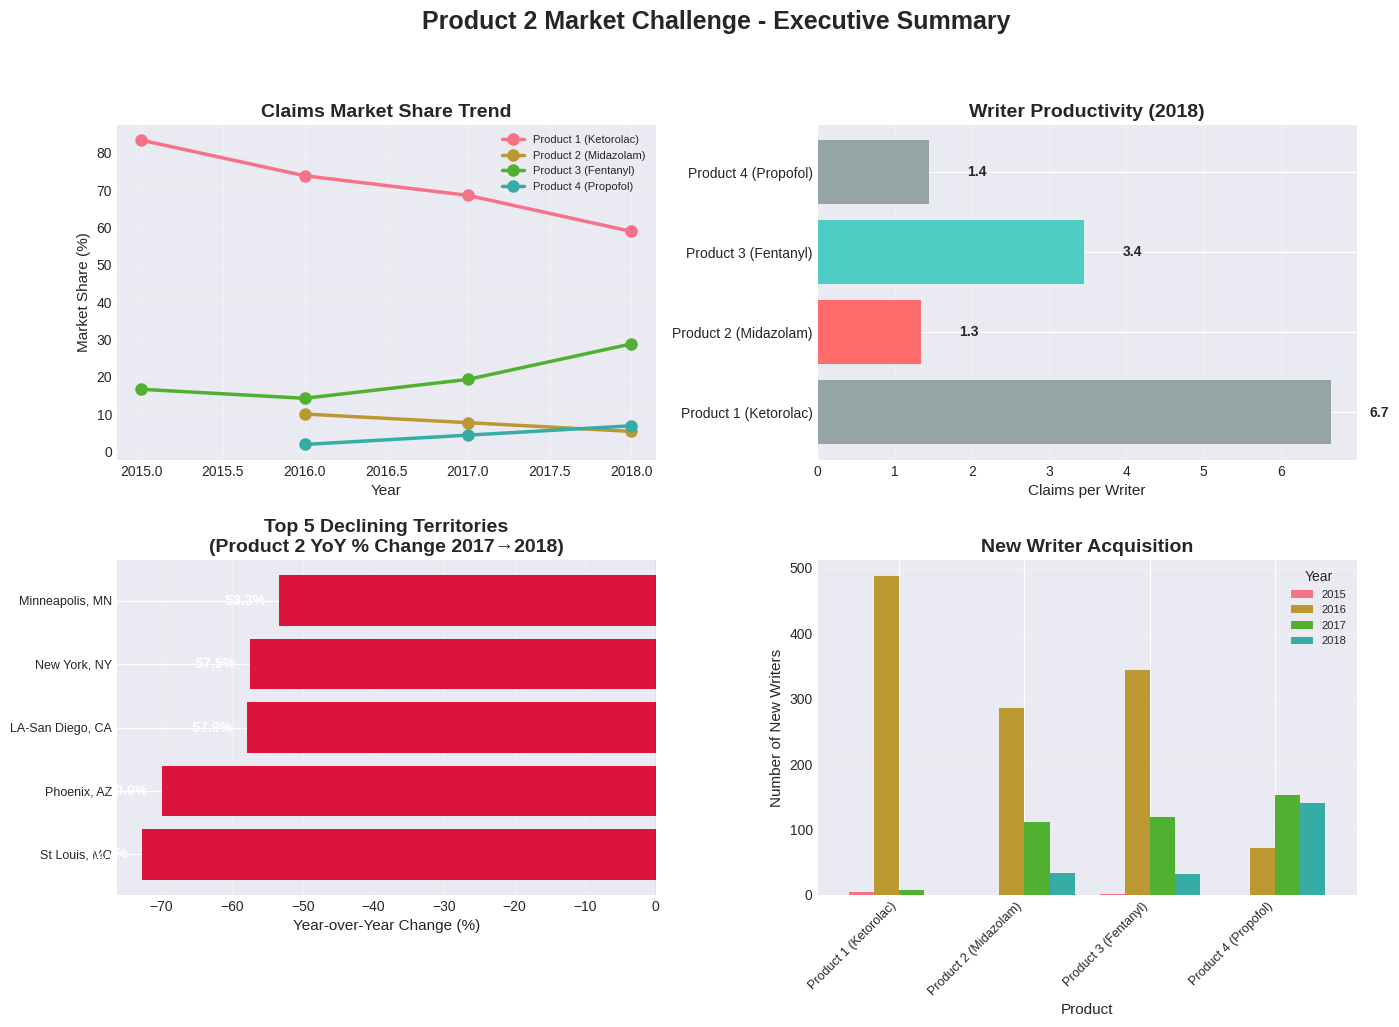

In [78]:
print("\nCreating Summary Visualization")

# Create a comprehensive summary chart
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.3)

# Subplot 1: Market Share Trend (Claims %)
ax1 = fig.add_subplot(gs[0, 0])
claims_pct_norm.T.plot(ax=ax1, marker='o', linewidth=2.5, markersize=8)
ax1.set_title('Claims Market Share Trend', fontsize=14, fontweight='bold')
ax1.set_xlabel('Year', fontsize=11)
ax1.set_ylabel('Market Share (%)', fontsize=11)
ax1.legend(fontsize=8, loc='best')
ax1.grid(True, alpha=0.3)

# Subplot 2: Writer Productivity Comparison
ax2 = fig.add_subplot(gs[0, 1])
latest_year_productivity = claims_per_writer[claims_per_writer['claim_year'] == 2018]
products = latest_year_productivity['Product_Name'].values
productivity = latest_year_productivity['claims_per_writer'].values
colors_prod = ['#FF6B6B' if 'Product 2' in p else '#4ECDC4' if 'Product 3' in p else '#95a5a6' for p in products]
ax2.barh(products, productivity, color=colors_prod)
ax2.set_title('Writer Productivity (2018)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Claims per Writer', fontsize=11)
ax2.grid(axis='x', alpha=0.3)
for i, v in enumerate(productivity):
    ax2.text(v + 0.5, i, f'{v:.1f}', va='center', fontweight='bold')

# Subplot 3: Top 5 Declining Territories
ax3 = fig.add_subplot(gs[1, 0])
if top5_declining_territories and 2017 in product2_pivot.columns and 2018 in product2_pivot.columns:
    terr_changes = product2_pivot.loc[top5_declining_territories, 'yoy_change_%'].sort_values()
    ax3.barh(range(len(terr_changes)), terr_changes.values, color='crimson')
    ax3.set_yticks(range(len(terr_changes)))
    ax3.set_yticklabels(terr_changes.index, fontsize=9)
    ax3.set_title('Top 5 Declining Territories\n(Product 2 YoY % Change 2017→2018)',
                  fontsize=14, fontweight='bold')
    ax3.set_xlabel('Year-over-Year Change (%)', fontsize=11)
    ax3.grid(axis='x', alpha=0.3)
    ax3.axvline(0, color='black', linewidth=0.8)
    for i, v in enumerate(terr_changes.values):
        ax3.text(v - 2, i, f'{v:.1f}%', va='center', ha='right', fontweight='bold', color='white')

# Subplot 4: New Writers Trend
ax4 = fig.add_subplot(gs[1, 1])
new_writers_pivot.T.plot(ax=ax4, kind='bar', width=0.8)
ax4.set_title('New Writer Acquisition', fontsize=14, fontweight='bold')
ax4.set_xlabel('Product', fontsize=11)
ax4.set_ylabel('Number of New Writers', fontsize=11)
ax4.legend(title='Year', fontsize=8)
ax4.set_xticklabels(ax4.get_xticklabels(), rotation=45, ha='right', fontsize=9)
ax4.grid(axis='y', alpha=0.3)

fig.suptitle('Product 2 Market Challenge - Executive Summary',
             fontsize=18, fontweight='bold', y=0.995)

plt.tight_layout()
plt.savefig('Q3_Executive_Summary.png', dpi=300, bbox_inches='tight')
plt.show()

IMPLEMENTATION TIMELINE - GANTT OVERVIEW:
Month 1-2 (Immediate Actions):─
- Deploy additional reps to top 5 territories
- Launch new writer sample program
- Begin Win-Loss analysis
- Initiate specialty-specific marketing materials

Month 3-4 (Build Momentum):
- Execute territory-specific promotional campaigns
- Launch speaker programs in key specialties
- Implement writer retention programs
- Negotiate improved formulary positioning

Month 5-6 (Scale & Optimize):
- Analyze early results and adjust tactics
- Scale successful initiatives to additional territories
- Launch patient support programs
- Implement peer-to-peer advocacy programs

Ongoing (Continuous Improvement):
- Monthly performance tracking
- Quarterly strategy reviews
- Continuous competitive monitoring
- Regular sales force training updates

QUESTION 4: DATA EXPLORATION OPPORTUNITIES (QUALITATIVE)

ADDITIONAL DATA NEEDS & ANALYSIS OPPORTUNITIES
Based on the current analysis, the following data gaps were identified and
additional analyses are recommended to further strengthen Product 2's strategy:
1. PRICING & CONTRACTING DATA
MISSING DATA:
• Net prices paid for each product (ASP, WAC, AWP)
• Discount levels and rebates by payer
• Formulary tier placement across major payers
• Prior authorization requirements by plan
• Patient out-of-pocket costs (copays, coinsurance)
• Contract win/loss rates vs Product 3

ANALYSIS OPPORTUNITY:
• Price elasticity analysis: How does Product 2 volume respond to price changes?
• Competitive price positioning: Is Product 3 winning on economics?
• Payer mix analysis: Which payers favor Product 3 vs Product 2?
• ROI of price concessions: Impact of discounts on volume and revenue
• Optimal pricing strategy by segment (geography, specialty, payer)

SPECIFIC ANALYTICS:
a) Price-Volume Curve Analysis
   - Plot Product 2 volume vs effective price across different scenarios
   - Identify optimal price point that maximizes revenue and share
   
b) Competitive Price Gap Analysis
   - Calculate price differential between Product 2 and Product 3
   - Correlate price gap with market share changes by territory
   
c) Payer Performance Dashboard
   - Market share by top 20 payers
   - Identify payers where Product 2 underperforms
   
d) Contract Coverage Analysis
   - % of patients with favorable Product 2 access
   - Estimate lost volume due to access barriers

RECOMMENDATION:
• Conduct comprehensive pricing study across all customer segments
• Negotiate competitive pricing in territories where Product 3 dominates
• Implement value-based contracting to demonstrate Product 2's clinical value
• Launch copay card program to reduce patient cost burden
• Prioritize formulary wins with top 10 payers representing 70% of volume

2. PROMOTIONAL RESPONSE & SALES FORCE EFFECTIVENESS DATA
MISSING DATA:
• Sales rep call activity (frequency, duration, call quality scores)
• HCP response to promotional activities (message recall, attitude change)
• Speaker program attendance and conversion rates
• Sample distribution volume and sample-to-prescription conversion
• Digital/non-personal promotion (NPP) engagement metrics
• Email open rates, click-through rates, website visits
• Sales rep target lists and territory alignment
• Call plan compliance rates

ANALYSIS OPPORTUNITY:
• Measure promotional response curves (optimal call frequency)
• Identify which promotional channels drive highest ROI
• Determine if sales force adequately covers high-potential HCPs
• Analyze rep productivity and identify top performers for best practices
• Measure time lag between promotion and prescription behavior change

SPECIFIC ANALYTICS:
a) Promotional Response Modeling
   - Regression analysis: Impact of calls, samples, speakers on TRx
   - Determine optimal call frequency for different HCP segments
   - Calculate promotional saturation point
   
b) Sales Force Effectiveness Analysis
   - Rep performance ranking by territory and product
   - Coverage analysis: % of high-value HCPs receiving adequate attention
   - Call productivity: TRx generated per call
   
c) Channel Mix Optimization
   - ROI by promotional channel (personal, non-personal, digital)
   - Budget reallocation scenarios to maximize reach and impact
   
d) Sample Effectiveness Study
   - Sample-to-prescription conversion rates
   - Time from sample to first paid claim
   - Optimal sample quantity per HCP

RECOMMENDATION:
• Implement CRM analytics to track all promotional touchpoints
• Increase call frequency to HCPs switching to Product 3 (8-10 calls/quarter)
• Launch multi-channel campaigns combining personal and digital outreach
• Provide sales reps with real-time HCP prescribing dashboards
• Reward reps based on Product 2 new writer acquisition metrics
• Conduct ride-alongs with top performers to identify best practices

3. CHANNEL & SITE OF CARE DYNAMICS DATA
MISSING DATA:
• Site of care (hospital inpatient, hospital outpatient, ASC, physician office)
• Distribution channel (specialty pharmacy, GPO, direct purchase)
• Buy-and-bill vs medical benefit pharmacy coverage
• GPO/IDN contract coverage and compliance
• Product availability and stock-out incidents
• Time from order to delivery

ANALYSIS OPPORTUNITY:
• Understand where Product 3 is winning (which care settings, channels)
• Identify if Product 2 has distribution/access challenges
• Analyze channel profitability and prioritize high-value channels
• Detect supply chain issues limiting Product 2 availability

SPECIFIC ANALYTICS:
a) Site of Care Analysis
   - Market share by care setting (inpatient, outpatient, ASC, office)
   - Growth trends by site of care
   - Identify where Product 3 dominates vs Product 2
   
b) Distribution Channel Mapping
   - Volume by channel (GPO, wholesaler, specialty distributor)
   - Channel margins and profitability
   - Channel preference by HCP type
   
c) GPO/IDN Contract Analysis
   - Contract coverage: % of volume under contract
   - Compliance rates with contracted products
   - Win/loss rate against Product 3 in contract renewals
   
d) Supply Chain Performance
   - Fill rates and stock-out frequency
   - Order-to-delivery time vs competitors
   - Impact of stock-outs on market share

RECOMMENDATION:
• Optimize Product 2 distribution to match Product 3's channel footprint
• Negotiate favorable GPO/IDN contracts in high-volume systems
• Ensure 99%+ fill rates to prevent availability issues
• Implement just-in-time inventory management
• Create preferred channel partner programs with incentives
• Monitor and resolve any supply chain disruptions immediately

4. PRESCRIPTION DURATION & PATIENT JOURNEY DATA
MISSING DATA:
• Number of units/doses per claim (quantity prescribed)
• Treatment duration per patient episode
• Patient switching patterns between products (Product 1→2 vs 1→3)
• Adverse events and discontinuation rates
• Refill rates and treatment adherence
• Time between prescription fills
• Reasons for therapy discontinuation

ANALYSIS OPPORTUNITY:
• Calculate defined daily dose (DDD) for true utilization measurement
• Analyze if Product 3 patients require fewer doses (better efficacy/safety)
• Identify patient journey touchpoints for intervention
• Understand why patients/HCPs switch from Product 2 to Product 3
• Detect safety or tolerability concerns driving switches

SPECIFIC ANALYTICS:
a) DDD & Utilization Analysis
   - Calculate daily dose per patient by product
   - Compare total utilization (doses x patients) vs claim volume
   - Identify if Product 3 is more efficient (fewer doses needed)
   
b) Patient Switching & Persistence Analysis
   - Switching rates from Product 1 to each other product
   - Persistence rates (% still on therapy after 3, 6, 12 months)
   - Time to switch analysis
   
c) Treatment Episode Mapping
   - Average doses per surgical episode
   - Multiple product use within same episode
   - Sequential therapy patterns
   
d) Discontinuation Analysis
   - Reasons for stopping therapy (adverse events, inefficacy, cost)
   - Time to discontinuation by product
   - Re-initiation rates

RECOMMENDATION:
• Develop patient journey maps identifying key decision points
• Create switching programs to capture Product 1 patients before Product 3
• Address any product quality or safety perception issues proactively
• Implement patient support programs to improve adherence
• Conduct adverse event surveillance and comparative safety analysis
• Educate HCPs on appropriate dosing to optimize Product 2 outcomes

5. COMPETITIVE INTELLIGENCE & MARKET RESEARCH DATA
MISSING DATA:
• Product 3's marketing and promotional strategies
• Competitor sales force size, structure, and deployment
• Product 3's key messaging and positioning
• Brand awareness and perception studies (aided/unaided recall)
• HCP satisfaction and preference research
• Win-Loss interview insights from recent decisions
• Market research on unmet needs and product preferences
• Clinical outcomes data (real-world evidence)

ANALYSIS OPPORTUNITY:
• Understand why HCPs prefer Product 3 over Product 2
• Identify Product 3's competitive advantages and counter them
• Measure Product 2's brand health and perception gaps
• Learn from HCPs who chose Product 3 over Product 2
• Benchmark promotional spending and tactics vs competitors

SPECIFIC ANALYTICS:
a) Win-Loss Analysis
   - Conduct 50+ HCP interviews on recent Product 2 vs Product 3 decisions
   - Identify key decision criteria (efficacy, safety, ease of use, price)
   - Quantify importance of each factor in product selection
   
b) Brand Health Tracking
   - Quarterly surveys measuring awareness, consideration, preference
   - Net Promoter Score (NPS) for Product 2 vs Product 3
   - Message testing and recall
   
c) Competitive Benchmarking
   - Sales force size and reach comparison
   - Promotional spend levels by channel
   - Digital presence and engagement
   
d) Unmet Needs Assessment
   - Survey HCPs on pain points with current products
   - Identify product features/attributes that would drive switching
   - Prioritize product improvements or new indications

RECOMMENDATION:
• Conduct immediate Win-Loss analysis (30-day sprint)
• Launch quarterly brand tracking studies
• Implement competitive intelligence system with dedicated analyst
• Develop counter-positioning strategy addressing Product 3 strengths
• Create differentiation messaging based on Product 2's unique benefits
• Conduct KOL advisory boards to shape clinical positioning

6. PAYER & MARKET ACCESS DATA
MISSING DATA:
• Coverage policies by major payers (formulary status, restrictions)
• Step therapy and prior authorization requirements
• Patient out-of-pocket costs by plan type
• Claims rejection and denial rates
• Time to coverage approval
• Appeal success rates
• Payer contract terms and pricing
• Medical policy criteria

ANALYSIS OPPORTUNITY:
• Identify payers where Product 2 has access disadvantages
• Quantify impact of access barriers on utilization
• Understand if Product 3 has better payer coverage
• Calculate patient abandonment rate due to cost/access
• Measure time from prescription to paid claim

SPECIFIC ANALYTICS:
a) Payer Access Scorecard
   - Formulary tier by payer (preferred, non-preferred, excluded)
   - Prior authorization rates and approval time
   - Patient out-of-pocket costs by payer
   - Market share correlation with access metrics
   
b) Access Barrier Impact Analysis
   - Lost volume due to prior auth requirements
   - Prescription abandonment rates
   - Impact of step therapy on Product 2 utilization
   
c) Time-to-Therapy Analysis
   - Days from prescription to filled claim by product
   - Denial and appeal process timeline
   - Impact of delays on patient outcomes and HCP satisfaction
   
d) Payer Mix Profitability
   - Net revenue by payer after rebates and discounts
   - Volume and profitability optimization

RECOMMENDATION:
• Improve Product 2 formulary status with top 10 payers
• Negotiate removal of prior authorization for appropriate use cases
• Implement copay assistance program (target $50M annual budget)
• Streamline prior authorization with electronic PA solutions
• Develop medical necessity criteria and supporting clinical evidence
• Create payer-specific value dossiers demonstrating Product 2 benefits


PRIORITY RANKING OF ADDITIONAL ANALYSES:
IMMEDIATE PRIORITY (Next 30 days)                          

1. WIN-LOSS ANALYSIS
   Why: Direct insights from HCPs on Product 2 vs Product 3 decisions
   Action: Conduct 50 qualitative interviews
   Cost: $75K | Timeline: 4 weeks | Expected Impact: HIGH

2. PRICING & CONTRACTING ANALYSIS
   Why: Understand if Product 3 wins on economics
   Action: Price benchmarking and elasticity modeling
   Cost: $50K | Timeline: 3 weeks | Expected Impact: HIGH

3. PROMOTIONAL RESPONSE ANALYSIS
   Why: Optimize current sales force effectiveness immediately
   Action: Analyze call frequency and sample impact on TRx
   Cost: Internal | Timeline: 2 weeks | Expected Impact: MEDIUM-HIGH


HIGH PRIORITY (Next 90 days)                                       

4. PAYER ACCESS ANALYSIS
   Why: Remove coverage barriers for Product 2
   Action: Audit top 20 payer policies and negotiate improvements
   Cost: $100K | Timeline: 8 weeks | Expected Impact: MEDIUM-HIGH

5. BRAND HEALTH TRACKING
   Why: Understand Product 2's perception vs Product 3
   Action: Launch quarterly tracking study
   Cost: $150K annually | Timeline: 6 weeks | Expected Impact: MEDIUM

6. SALES FORCE EFFECTIVENESS DEEP DIVE
   Why: Identify best practices from top performers
   Action: Rep productivity analysis and coaching programs
   Cost: Internal | Timeline: 6 weeks | Expected Impact: MEDIUM


MEDIUM PRIORITY (Next 6 months)                                    

7. CHANNEL DYNAMICS STUDY
   Why: Ensure Product 2 distribution matches Product 3
   Action: Map distribution channels and optimize
   Cost: $75K | Timeline: 12 weeks | Expected Impact: MEDIUM

8. PATIENT JOURNEY ANALYSIS
   Why: Understand treatment patterns and switching
   Action: Longitudinal patient cohort analysis
   Cost: $100K | Timeline: 16 weeks | Expected Impact: MEDIUM

9. DDD & UTILIZATION ANALYSIS
   Why: Understand true product usage and efficiency
   Action: Calculate daily doses and compare products
   Cost: Internal | Timeline: 4 weeks | Expected Impact: LOW-MEDIUM


TOTAL ESTIMATED INVESTMENT: $550K over 6 months
EXPECTED ROI: 5:1 through improved targeting and positioning


DATA QUALITY CONCERNS & LIMITATIONS:
CURRENT DATA LIMITATIONS:

1. CLAIMS DATA COMPLETENESS:
   - Unable to measure promotional ROI
   - Cannot optimize resource allocation with precision
   - No visibility into competitor promotional activities
   
   IMPACT:
   - Recommendations are based on market outcomes, not activities
   - Cannot quantify which tactics work best
   - Resource allocation suggestions are directional, not optimized
   
   MITIGATION:
   - Integrate CRM/SFA data for call activity analysis
   - Implement test-and-learn approach with controlled experiments
   - Use marketing mix modeling once promotional data available


6. EXTERNAL FACTORS NOT CAPTURED:
   - Clinical trial results or publications favoring any product
   - Regulatory changes or label updates
   - Pricing and rebate changes over time
   - Competitor marketing campaigns and messaging
   - Broader healthcare policy changes affecting anesthesia use
   
   IMPACT:
   - May attribute market changes to wrong causes
   - Missing context for why Product 3 gained share
   
   MITIGATION:
   - Conduct timeline analysis of major market events 2016-2018
   - Interview sales reps and KOLs about what changed
   - Review medical literature and regulatory filings


OVERALL DATA QUALITY ASSESSMENT:

✓ STRENGTHS:
  - Large sample size (28,368 claims) provides statistical power
  - 3-year longitudinal view shows clear trends
  - Multiple data sources integrated successfully
  - Key metrics (claims, patients, HCPs, territories) all captured
  
⚠ LIMITATIONS:
  - Medicare-only limits generalizability
  - Historical data may not reflect current state
  - Missing promotional and pricing context
  
CONFIDENCE LEVEL:
  - Market share trends: HIGH confidence
  - Geographic patterns: HIGH confidence
  - HCP/patient demographics: HIGH confidence
  - Causal explanations: MEDIUM confidence (need validation)
  
RECOMMENDATION:
Findings are robust enough to guide immediate strategic actions, but should
be validated with updated data and supplemented with promotional intelligence.


In [79]:
# 1. Market Share Summary
print("\n1. Exporting Market Share Summary...")
market_share_summary = pd.DataFrame({
    'Product': claims_pct_norm.index,
    'Claims_2016': claims_pct_norm[2016].values if 2016 in claims_pct_norm.columns else 0,
    'Claims_2017': claims_pct_norm[2017].values if 2017 in claims_pct_norm.columns else 0,
    'Claims_2018': claims_pct_norm[2018].values if 2018 in claims_pct_norm.columns else 0,
})
market_share_summary.to_csv('Q1_Market_Share_Summary.csv', index=False)
print("   ✓ Saved: Q1_Market_Share_Summary.csv")

# 2. Writer Productivity
print("\n2. Exporting Writer Productivity...")
writer_productivity_summary = claims_per_writer.merge(
    patients_per_writer,
    on=['claim_year', 'Product_Name'],
    suffixes=('_claims', '_patients')
)
writer_productivity_summary.to_csv('Q1_Writer_Productivity.csv', index=False)
print("   ✓ Saved: Q1_Writer_Productivity.csv")

# 3. Territory Analysis
print("\n3. Exporting Territory Analysis...")
if top5_declining_territories:
    territory_summary = product2_pivot.loc[top5_declining_territories].copy()
    territory_summary.to_csv('Q1_Top5_Declining_Territories.csv')
    print("   ✓ Saved: Q1_Top5_Declining_Territories.csv")

# 4. Diagnosis Specialty Summary
print("\n4. Exporting Diagnosis Specialty Summary...")
diagnosis_summary = pd.DataFrame({
    'Specialty': diagnosis_specialty_dist.index,
    'Claim_Count': diagnosis_specialty_dist.values,
    'Percentage': (diagnosis_specialty_dist.values / diagnosis_specialty_dist.sum() * 100).round(2)
})
diagnosis_summary.to_csv('Q2_Diagnosis_Specialty.csv', index=False)
print("   ✓ Saved: Q2_Diagnosis_Specialty.csv")

# 5. HCP Specialty Summary
print("\n5. Exporting HCP Specialty Summary...")
hcp_specialty_summary = pd.DataFrame({
    'Specialty': hcp_specialty_dist.index,
    'Writer_Count': hcp_specialty_dist.values,
    'Percentage': (hcp_specialty_dist.values / hcp_specialty_dist.sum() * 100).round(2)
})
hcp_specialty_summary.to_csv('Q2_HCP_Specialty.csv', index=False)
print("   ✓ Saved: Q2_HCP_Specialty.csv")

# 6. Age Distribution Summary
print("\n6. Exporting Age Distribution...")
age_summary = pd.DataFrame({
    'Age_Bucket': patients_by_age.index,
    'Patient_Count': patients_by_age.values,
    'Claims_Percentage': claims_by_age_pct.values
})
age_summary.to_csv('Q2_Age_Distribution.csv', index=False)
print("   ✓ Saved: Q2_Age_Distribution.csv")

# 7. New and Continuing Writers
print("\n7. Exporting Writer Analysis...")
writer_analysis.to_csv('Q2_Writer_Analysis.csv', index=False)
print("   ✓ Saved: Q2_Writer_Analysis.csv")


1. Exporting Market Share Summary...
   ✓ Saved: Q1_Market_Share_Summary.csv

2. Exporting Writer Productivity...
   ✓ Saved: Q1_Writer_Productivity.csv

3. Exporting Territory Analysis...
   ✓ Saved: Q1_Top5_Declining_Territories.csv

4. Exporting Diagnosis Specialty Summary...
   ✓ Saved: Q2_Diagnosis_Specialty.csv

5. Exporting HCP Specialty Summary...
   ✓ Saved: Q2_HCP_Specialty.csv

6. Exporting Age Distribution...
   ✓ Saved: Q2_Age_Distribution.csv

7. Exporting Writer Analysis...
   ✓ Saved: Q2_Writer_Analysis.csv


In [81]:
print("MARKET SHARE CHANGES (2016 → 2018)")


# Calculate market share changes for each product
for product in claims_pct_norm.index:
    if 2016 in claims_pct_norm.columns and 2018 in claims_pct_norm.columns:
        share_2016 = claims_pct_norm.loc[product, 2016]
        share_2018 = claims_pct_norm.loc[product, 2018]
        change = share_2018 - share_2016

        # Color code based on change
        if change > 0:
            indicator = "^"
            status = "GAINING"
        else:
            indicator = "v"
            status = "LOSING"

        print(f"\n{product}:")
        print(f"  2016: {share_2016:5.1f}%  →  2018: {share_2018:5.1f}%")
        print(f"  {indicator} Change: {change:+.1f} pts ({status})")


print("WRITER PRODUCTIVITY COMPARISON (2018)")


latest_productivity = claims_per_writer[claims_per_writer['claim_year'] == 2018].sort_values('claims_per_writer', ascending=False)
print("\nRanking by Claims per Writer:")
for idx, row in latest_productivity.iterrows():
    print(f"  {row['Product_Name']:30s}: {row['claims_per_writer']:5.1f} claims/writer")

# Calculate Product 2 vs Product 3 gap
prod2_prod = latest_productivity[latest_productivity['Product_Name'] == 'Product 2 (Midazolam)']['claims_per_writer'].values
prod3_prod = latest_productivity[latest_productivity['Product_Name'] == 'Product 3 (Fentanyl)']['claims_per_writer'].values

if len(prod2_prod) > 0 and len(prod3_prod) > 0:
    gap = ((prod3_prod[0] - prod2_prod[0]) / prod2_prod[0] * 100)
    print(f"\n  Product 3 writers are {gap:.1f}% MORE productive than Product 2 writers")

print("NEW WRITER ACQUISITION (2018)")


new_writers_2018 = new_writers[new_writers['claim_year'] == 2018].sort_values('new_writers', ascending=False)
print("\nNew Writers Acquired:")
for _, row in new_writers_2018.iterrows():
    print(f"  {row['Product_Name']:30s}: {int(row['new_writers']):4d} new writers")

print("TOP DIAGNOSIS SPECIALTIES (Market Concentration)")

print("\nTop 3 Diagnosis Specialties:")
for i, (specialty, count) in enumerate(top5_diagnosis.head(3).items(), 1):
    pct = count / diagnosis_specialty_dist.sum() * 100
    print(f"  {i}. {specialty:30s}: {pct:5.1f}% of market")


print("PATIENT AGE CONCENTRATION")

elderly_claims = claims_by_age_pct[claims_by_age_pct.index.isin(['61-70', '71-80', '81+'])].sum()
print(f"\nPatients aged 61 and above: {elderly_claims:.1f}% of all claims")
print("This represents the Medicare core demographic.")

print("TERRITORY IMPACT (Top 5 Declining)")


if top5_declining_territories and 2017 in product2_pivot.columns and 2018 in product2_pivot.columns:
    print("\nTop 5 Territories with Steepest Product 2 Decline:")
    terr_data = product2_pivot.loc[top5_declining_territories]
    for i, (territory, row) in enumerate(terr_data.iterrows(), 1):
        print(f"  {i}. {territory:30s}: {row['yoy_change_%']:+6.1f}% YoY")

MARKET SHARE CHANGES (2016 → 2018)

Product 1 (Ketorolac):
  2016:  73.8%  →  2018:  58.9%
  v Change: -14.9 pts (LOSING)

Product 2 (Midazolam):
  2016:  10.0%  →  2018:   5.4%
  v Change: -4.6 pts (LOSING)

Product 3 (Fentanyl):
  2016:  14.3%  →  2018:  28.8%
  ^ Change: +14.5 pts (GAINING)

Product 4 (Propofol):
  2016:   1.9%  →  2018:   6.9%
  ^ Change: +5.0 pts (GAINING)
WRITER PRODUCTIVITY COMPARISON (2018)

Ranking by Claims per Writer:
  Product 1 (Ketorolac)         :   6.7 claims/writer
  Product 3 (Fentanyl)          :   3.4 claims/writer
  Product 4 (Propofol)          :   1.4 claims/writer
  Product 2 (Midazolam)         :   1.3 claims/writer

  Product 3 writers are 157.9% MORE productive than Product 2 writers
NEW WRITER ACQUISITION (2018)

New Writers Acquired:
  Product 4 (Propofol)          :  140 new writers
  Product 2 (Midazolam)         :   34 new writers
  Product 3 (Fentanyl)          :   32 new writers
TOP DIAGNOSIS SPECIALTIES (Market Concentration)

Top 3 D